# 17 & 18: Separate RRab and RRc Fits

This notebook fits the Gaia $G$-band period-luminosity relation **separately** for the two main RR Lyrae subclasses in the cleaned calibration sample. That split is astrophysically motivated: **RRab** stars pulsate in the radial fundamental mode, whereas **RRc** stars pulsate in the first overtone, so they need not follow exactly the same optical $P$-$L$ relation. Recent calibration work finds that, for practical distance work, it is safer to derive RRab and RRc relations separately rather than rely on a mixed fit with fundamentalized overtone periods ([Narloch et al. 2024](https://www.aanda.org/articles/aa/full_html/2024/09/aa50364-24/aa50364-24.html); [Klein et al. 2014](https://academic.oup.com/mnrasl/article/440/1/L96/1396776)).

This notebook therefore performs three Bayesian fits for **RRab** and three Bayesian fits for **RRc**:

1. custom Metropolis-Hastings,
2. PyMC NUTS with the likelihood added through `pm.Potential`,
3. PyMC NUTS with the same model expressed natively through `pm.Normal(..., observed=...)`.

These are not three different astrophysical period-luminosity models. They are three computational routes to the same subclass-specific posterior, used here to make the Bayesian workflow explicit and to check that the numerical implementations agree.


In [1]:
from pathlib import Path
from types import SimpleNamespace

from astropy import table
import corner
import matplotlib.pyplot as plt
import numpy as np
import pymc as pm
import pytensor.tensor as pt

from ugdatalab import (
    MetropolisHastings,
    NoUTurnHamiltonian,
    plot_pl_sampler_comparison_corner,
    build_optical_pl_comparison_data,
    build_pl_context,
    fit_pl_nuts_native,
    fit_pl_nuts_potential,
    load_table_npz,
    pl_posterior_summary_row,
    plot_corner,
    plot_pl_posterior_predictive,
    plot_pl_posterior_predictive_comparison,
    mcmc_sampler_color,
    plot_trace,
    save_optical_pl_comparison_data,
)

In [2]:
data_path = Path("rrlyrae_calibration_sample.npz")
rrlyrae_clean_data = load_table_npz(data_path)

len(rrlyrae_clean_data), rrlyrae_clean_data.colnames[:8]


(884,
 ['solution_id',
  'source_id',
  'pf',
  'pf_error',
  'p1_o',
  'p1_o_error',
  'epoch_g',
  'epoch_g_error'])

## Why Split RRab and RRc, and Why Exclude RRd?

Gaia DR3 treats **RRab**, **RRc**, and **RRd** as distinct RR Lyrae subclasses because they correspond to different pulsation behaviour and light-curve morphology ([Clementini et al. 2023](https://www.aanda.org/articles/aa/full_html/2023/06/aa43964-22/aa43964-22.html)). In that classification scheme, RRab are fundamental-mode pulsators, RRc are first-overtone pulsators, and RRd are **double-mode** stars that simultaneously excite the fundamental and first-overtone modes.

That distinction matters for period-luminosity calibration. Narloch et al. argue that, for distance estimation, one should use **RRab and RRc relations separately**, because mixed fits can produce subclass-dependent offsets even after “fundamentalizing” RRc periods ([Narloch et al. 2024](https://www.aanda.org/articles/aa/full_html/2024/09/aa50364-24/aa50364-24.html)). Earlier RR Lyrae calibration work also commonly fit overtone and fundamental stars separately or transformed overtone stars with explicit care before combining them ([Klein et al. 2014](https://academic.oup.com/mnrasl/article/440/1/L96/1396776)).

RRd is different again. Recent work shows that RRd stars admit their own distance relation involving both the pulsation period and the **period ratio**, precisely because the double-mode structure carries extra physical information ([Shi et al. 2023](https://doi.org/10.1038/s41550-023-02011-y)). That is not the same problem as fitting a simple two-parameter optical $M_G = a \log_{10}(P/{\rm day}) + b$ relation. Because the cleaned sample here contains only a handful of RRd stars, this notebook excludes RRd from the fit and focuses on the two well-populated subclasses.


In [3]:
classes = np.asarray(rrlyrae_clean_data["best_classification"]).astype(str)
class_labels, class_counts = np.unique(classes, return_counts=True)
class_count_table = table.Table({"class": class_labels, "N": class_counts})

rrab_data = rrlyrae_clean_data[classes == "RRab"]
rrc_data = rrlyrae_clean_data[classes == "RRc"]
rrd_data = rrlyrae_clean_data[classes == "RRd"]

class_count_table


class,N
str4,int64
RRab,560
RRc,316
RRd,8


A pure optical $G$-band period-luminosity relation is physically simple but not maximally clean. The Gaia $G$ band is broad, so subclass-dependent light-curve morphology, temperature sensitivity, metallicity dependence, and any residual extinction can all broaden the relation. Published RR Lyrae distance work often moves beyond a bare optical PL law to PLZ or Wesenheit-like constructions for exactly that reason. In this notebook I keep the model intentionally simple so that the Bayesian fitting machinery is transparent, while allowing $\sigma_{\rm scatter}$ to absorb the remaining unresolved width.


The cleaned handoff table already contains the derived absolute magnitudes $M_G$ and their uncertainties $\sigma_M$ from the previous notebook. This notebook conditions on those quantities as fixed inputs. That keeps the Bayesian model focused on the period-luminosity relation itself, but it also means the inverse-parallax and extinction-related caveats from `02-01.ipynb` are inherited rather than re-derived here.


## Class-Specific Bayesian Model and Priors

For each subclass separately, I fit

$$M_G = a\,x_c + b,$$

with

$$x = \log_{10}(P/{\rm day}), \qquad x_c = x - \bar{x}_{\rm class}.$$

Centering the predictor within each class makes the intercept more interpretable and reduces posterior correlation between slope and intercept. Here the intercept $b$ should be interpreted as the expected absolute magnitude at the **mean log-period of that subclass**, not at $\log_{10}P = 0$.

I also propagate the Gaia catalog period uncertainties. For each subclass I convert the relevant period error to log-period uncertainty,

$$\sigma_{\log P,i} = \frac{\sigma_{P,i}}{P_i\ln 10},$$

and use the likelihood

$$M_{G,i} \sim \mathcal{N}\!\left(a\,x_{c,i} + b,\; \sigma_{M,i}^2 + a^2\sigma_{\log P,i}^2 + \sigma_{\rm scatter}^2\right).$$

This keeps the observational $M_G$ uncertainty, the propagated period term, and the intrinsic class-dependent width $\sigma_{\rm scatter}$ conceptually distinct.

I keep the same weakly informative priors as before, but apply them independently to each subclass:

- $a \sim \mathcal{N}(0, 5)$,
- $b \sim \mathcal{N}(\mathrm{median}(M_G), 1\,{\rm mag})$ within that class,
- $\sigma_{\rm scatter} \sim \mathrm{HalfNormal}(0.5\,{\rm mag})$.

This notebook still works in direct $M_G$ space for pedagogical clarity. In the Gaia/RR Lyrae calibration literature, the more common final-publication alternatives are ABL, parallax-space Bayesian likelihoods, and hierarchical Bayesian PL/PLZ models. Those are widely used approaches rather than special-case workarounds ([Gaia Collaboration et al. 2017](https://www.aanda.org/articles/aa/full_html/2017/09/aa29925-16/aa29925-16.html); [Luri et al. 2018](https://www.aanda.org/articles/aa/full_html/2018/08/aa32964-18/aa32964-18.html); [Muraveva et al. 2018](https://academic.oup.com/mnras/article/481/1/1195/5075596); [Delgado et al. 2019](https://www.aanda.org/articles/aa/full_html/2019/03/aa32945-18/aa32945-18.html)).

The period-error term is also an approximation. Adding $a^2\sigma_{\log P}^2$ in quadrature is a first-order way to propagate uncertainty in the predictor through a linear relation in $\log_{10}P$. A fuller errors-in-variables or latent-period treatment would model the true period as an unobserved variable. That is beyond the scope of this notebook, but the approximation is still better than silently assuming the periods are exact.


In [4]:
DISPLAY_LABELS = [r"$a$", r"$b$", r"$\sigma_{\rm scatter}$"]
SLOPE_PRIOR_SIGMA = 5.0
INTERCEPT_PRIOR_SIGMA = 1.0
SIGMA_SCATTER_SCALE = 0.5
MH_PROPOSAL_GRID = [
    np.array([0.004, 0.008, 0.008]),
    np.array([0.005, 0.010, 0.010]),
    np.array([0.006, 0.012, 0.012]),
    np.array([0.008, 0.016, 0.016]),
    np.array([0.010, 0.020, 0.020]),
]


def log_prior_mh(theta, ctx):
    a, b, log10_sigma = theta
    if not np.all(np.isfinite(theta)):
        return -np.inf

    sigma_scatter = 10.0 ** log10_sigma
    if sigma_scatter <= 0.0:
        return -np.inf

    logp_a = -0.5 * (a / SLOPE_PRIOR_SIGMA) ** 2 - np.log(SLOPE_PRIOR_SIGMA * np.sqrt(2.0 * np.pi))
    logp_b = (
        -0.5 * ((b - ctx.intercept_prior_mean) / INTERCEPT_PRIOR_SIGMA) ** 2
        - np.log(INTERCEPT_PRIOR_SIGMA * np.sqrt(2.0 * np.pi))
    )
    logp_sigma = (
        0.5 * np.log(2.0 / np.pi)
        - np.log(SIGMA_SCATTER_SCALE)
        - 0.5 * (sigma_scatter / SIGMA_SCATTER_SCALE) ** 2
        + np.log(np.log(10.0) * sigma_scatter)
    )
    return logp_a + logp_b + logp_sigma


def log_likelihood_pl(theta, ctx):
    a, b, log10_sigma = theta
    sigma_scatter = 10.0 ** log10_sigma
    sigma2_tot = ctx.sigma**2 + sigma_scatter**2 + (a * ctx.sigma_logp) ** 2
    mu = a * ctx.x_centered + b
    return -0.5 * np.sum(np.log(2.0 * np.pi * sigma2_tot) + (ctx.y - mu) ** 2 / sigma2_tot)


def log_posterior_pl(theta, ctx):
    log_prior = log_prior_mh(theta, ctx)
    if not np.isfinite(log_prior):
        return -np.inf
    return log_prior + log_likelihood_pl(theta, ctx)


def build_display_sampler(samples, log_probs, n_burn):
    display_samples = np.asarray(samples, dtype=float).copy()
    display_samples[:, 2] = 10.0 ** display_samples[:, 2]
    return SimpleNamespace(
        samples=display_samples,
        log_probs=np.asarray(log_probs, dtype=float).copy(),
        n_burn=n_burn,
        param_labels=DISPLAY_LABELS,
    )


def proposal_scan(ctx):
    rows = []
    for proposal_std in MH_PROPOSAL_GRID:
        pilot = MetropolisHastings(
            log_prob=lambda theta, c=ctx: log_posterior_pl(theta, c),
            theta0=ctx.theta0,
            proposal_std=proposal_std,
            seed=42,
            labels=[r"$a$", r"$b$", r"$\log_{10}\sigma_{\rm scatter}$"],
        )
        pilot.run(n_steps=4_000, n_burn=500)
        rows.append(
            {
                "class": ctx.class_label,
                "proposal_std": proposal_std.tolist(),
                "acceptance": round(float(pilot.acceptance_rate), 3),
            }
        )
    return table.Table(rows=rows)


def run_mh_fit(ctx, proposal_std, n_steps=25_000, n_burn=5_000):
    sampler_raw = MetropolisHastings(
        log_prob=lambda theta, c=ctx: log_posterior_pl(theta, c),
        theta0=ctx.theta0,
        proposal_std=proposal_std,
        seed=42,
        labels=[r"$a$", r"$b$", r"$\log_{10}\sigma_{\rm scatter}$"],
    )
    sampler_raw.run(n_steps=n_steps, n_burn=n_burn)
    sampler_display = build_display_sampler(sampler_raw.samples, sampler_raw.log_probs, sampler_raw.n_burn)
    post_burn_samples = sampler_display.samples[sampler_display.n_burn:]
    summary = pl_posterior_summary_row("Metropolis-Hastings", ctx.class_label, post_burn_samples, sampler_raw.acceptance_rate)
    return SimpleNamespace(raw=sampler_raw, display=sampler_display, samples=post_burn_samples, summary=summary)


rrab_data = rrlyrae_clean_data[np.asarray(rrlyrae_clean_data["best_classification"]).astype(str) == "RRab"]
rrc_data = rrlyrae_clean_data[np.asarray(rrlyrae_clean_data["best_classification"]).astype(str) == "RRc"]
rrd_data = rrlyrae_clean_data[np.asarray(rrlyrae_clean_data["best_classification"]).astype(str) == "RRd"]

rrab_ctx = build_pl_context(rrab_data, "RRab")
rrc_ctx = build_pl_context(rrc_data, "RRc")
print({"RRab": rrab_ctx.n, "RRc": rrc_ctx.n, "RRd excluded": len(rrd_data)})

{'RRab': 560, 'RRc': 316, 'RRd excluded': 8}


## RRab Fit

RRab stars are the fundamental-mode RR Lyrae subclass. This section repeats the full three-sampler Bayesian workflow for the RRab-only subset.


The proposal scan below is only for the pedagogical random-walk Metropolis-Hastings branch. A random-walk sampler needs a hand-chosen proposal scale: if the steps are too small, the chain moves sluggishly and becomes highly autocorrelated; if they are too large, the chain proposes implausible jumps and rejects too often. Choosing a scale with acceptance of order $0.5$ is a useful classroom heuristic here, but it is not the governing principle for the NUTS runs that follow.


In [5]:
rrab_proposal_scan = proposal_scan(rrab_ctx)
rrab_proposal_std = np.array(
    min(rrab_proposal_scan, key=lambda row: abs(float(row["acceptance"]) - 0.5))["proposal_std"],
    dtype=float,
)
rrab_proposal_scan


class,proposal_std,acceptance
str4,float64[3],float64
RRab,0.004 .. 0.008,0.666
RRab,0.005 .. 0.01,0.593
RRab,0.006 .. 0.012,0.525
RRab,0.008 .. 0.016,0.422
RRab,0.01 .. 0.02,0.351


From the RRab proposal scan above, I choose the scale whose acceptance fraction is closest to the pedagogical target of order $0.5$ for the final Metropolis-Hastings run. That tuning choice is only meant to avoid obviously pathological random-walk behavior; it is not itself evidence that the RRab chain is converged or weakly correlated.


In [6]:
rrab_mh = run_mh_fit(rrab_ctx, rrab_proposal_std)
rrab_mh.summary


{'class': 'RRab',
 'method': 'Metropolis-Hastings',
 'acceptance': 0.549,
 'a': -2.2657,
 'a_minus': 0.1343,
 'a_plus': 0.1145,
 'b': 0.6531,
 'b_minus': 0.009,
 'b_plus': 0.0089,
 'sigma_scatter': 0.1761,
 'sigma_minus': 0.0073,
 'sigma_plus': 0.0074}

The next pair of diagnostics should be interpreted together. The trace plot shows whether the chain appears stationary and well mixed after burn-in, while the corner plot shows the marginal posterior widths and the covariance structure between slope, intercept, and intrinsic scatter. Because the predictor is centered before fitting, the slope-intercept correlation should be reduced relative to an uncentered fit, but not necessarily eliminated; an elongated corner contour is therefore expected posterior geometry, not automatically a sampler failure. In this notebook the samplers are run through single-chain wrappers, so these figures are informative but not exhaustive; a research workflow would normally add multi-chain diagnostics such as $\hat{R}$, effective sample size, lag-autocorrelation summaries, and NUTS divergence checks.


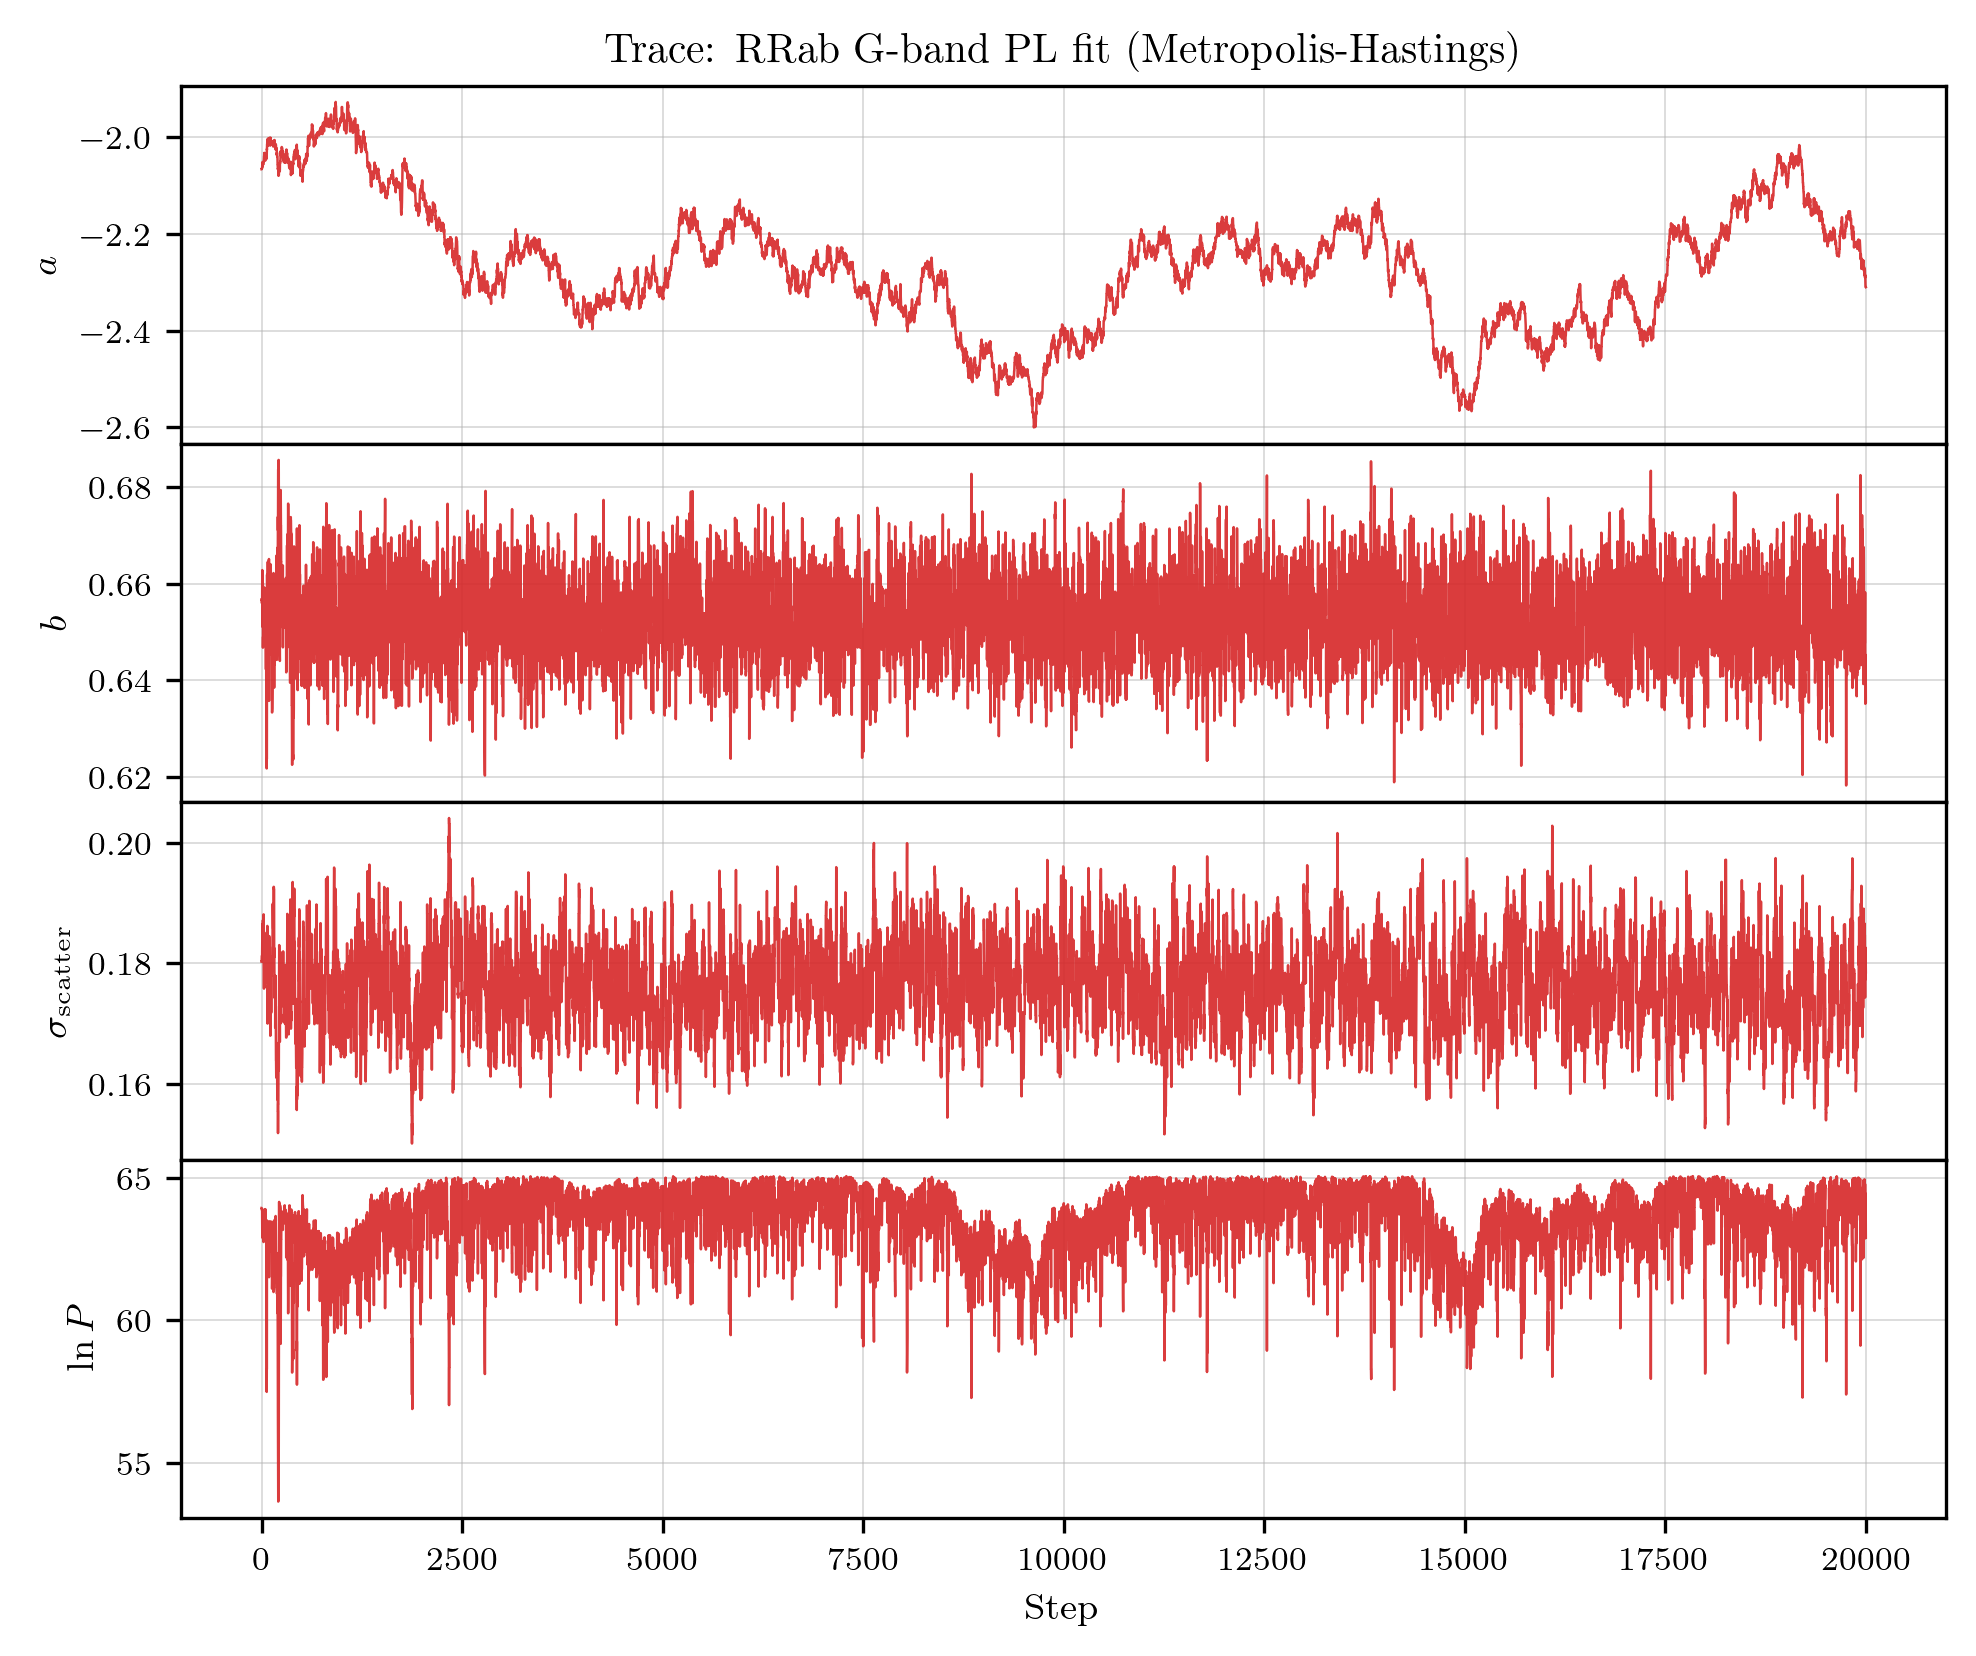

In [7]:
axes = plot_trace(
    rrab_mh.display.samples,
    rrab_mh.display.log_probs,
    rrab_mh.display.param_labels,
    rrab_mh.display.n_burn,
    color=mcmc_sampler_color("RRab", "mh"),
)
axes[0].set_title('Trace: RRab G-band PL fit (Metropolis-Hastings)')
plt.show()

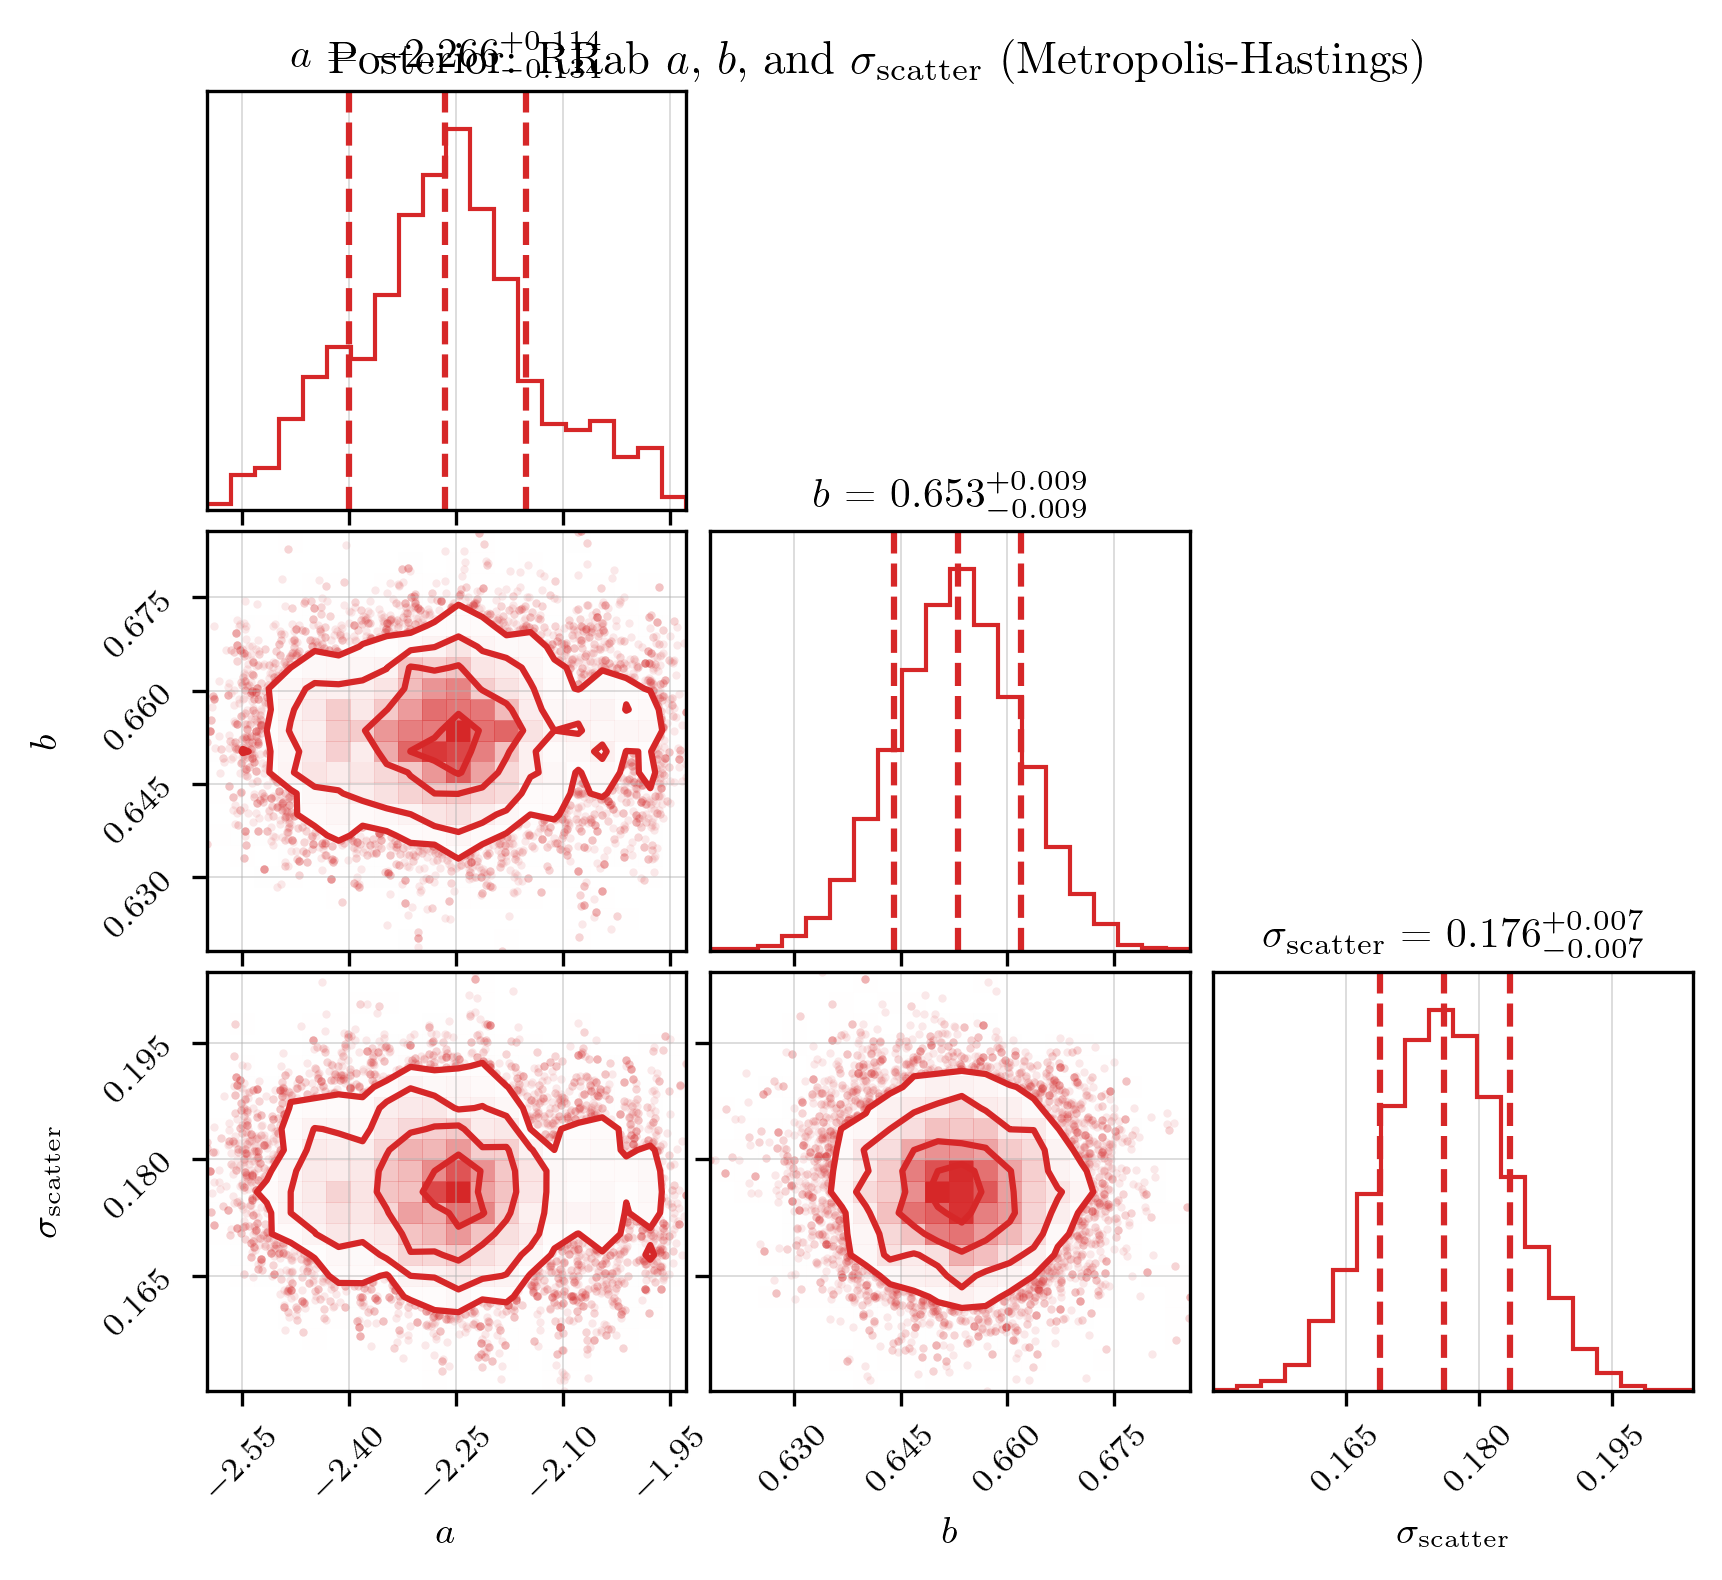

In [8]:
fig = plot_corner(
    rrab_mh.display,
    color=mcmc_sampler_color("RRab", "mh"),
    save="fig_mh_corner.pdf",
)
fig.suptitle(r'Posterior: RRab $a$, $b$, and $\sigma_{\rm scatter}$ (Metropolis-Hastings)')
plt.show()

The `pm.Potential` formulation below still uses the **No-U-Turn Sampler (NUTS)**, which is an adaptive Hamiltonian Monte Carlo method. Instead of making a local random-walk proposal like Metropolis-Hastings, NUTS uses gradients of the log posterior to generate long, coherent moves through parameter space and adaptively decides how far to follow each Hamiltonian trajectory before turning back. That usually makes it far more efficient than random-walk MH for correlated posteriors like the slope-intercept-scatter fit here, and it largely removes the need for hand-tuning a proposal width.

The `pm.Potential` formulation below is not a different physical model. It is the same likelihood written more manually inside PyMC so that the connection to the handwritten log-likelihood remains explicit. This is useful pedagogically because it shows how a custom posterior term can be inserted directly into a probabilistic-program model before moving on to the more idiomatic `observed=` form.

In [9]:
rrab_nuts_potential = fit_pl_nuts_potential(rrab_ctx)
rrab_nuts_potential.summary = pl_posterior_summary_row("NUTS + Potential", rrab_ctx.class_label, rrab_nuts_potential.samples, rrab_nuts_potential.acceptance_rate)
rrab_nuts_potential.summary

Initializing NUTS using jitter+adapt_diag...


Sequential sampling (1 chains in 1 job)


NUTS: [a, b, sigma_scatter]


Output()

Sampling 1 chain for 1_500 tune and 3_000 draw iterations (1_500 + 3_000 draws total) took 1 seconds.


Only one chain was sampled, this makes it impossible to run some convergence checks


{'class': 'RRab',
 'method': 'NUTS + Potential',
 'acceptance': 0.838,
 'a': -2.2296,
 'a_minus': 0.1366,
 'a_plus': 0.1239,
 'b': 0.653,
 'b_minus': 0.0085,
 'b_plus': 0.0084,
 'sigma_scatter': 0.176,
 'sigma_minus': 0.0073,
 'sigma_plus': 0.0075}

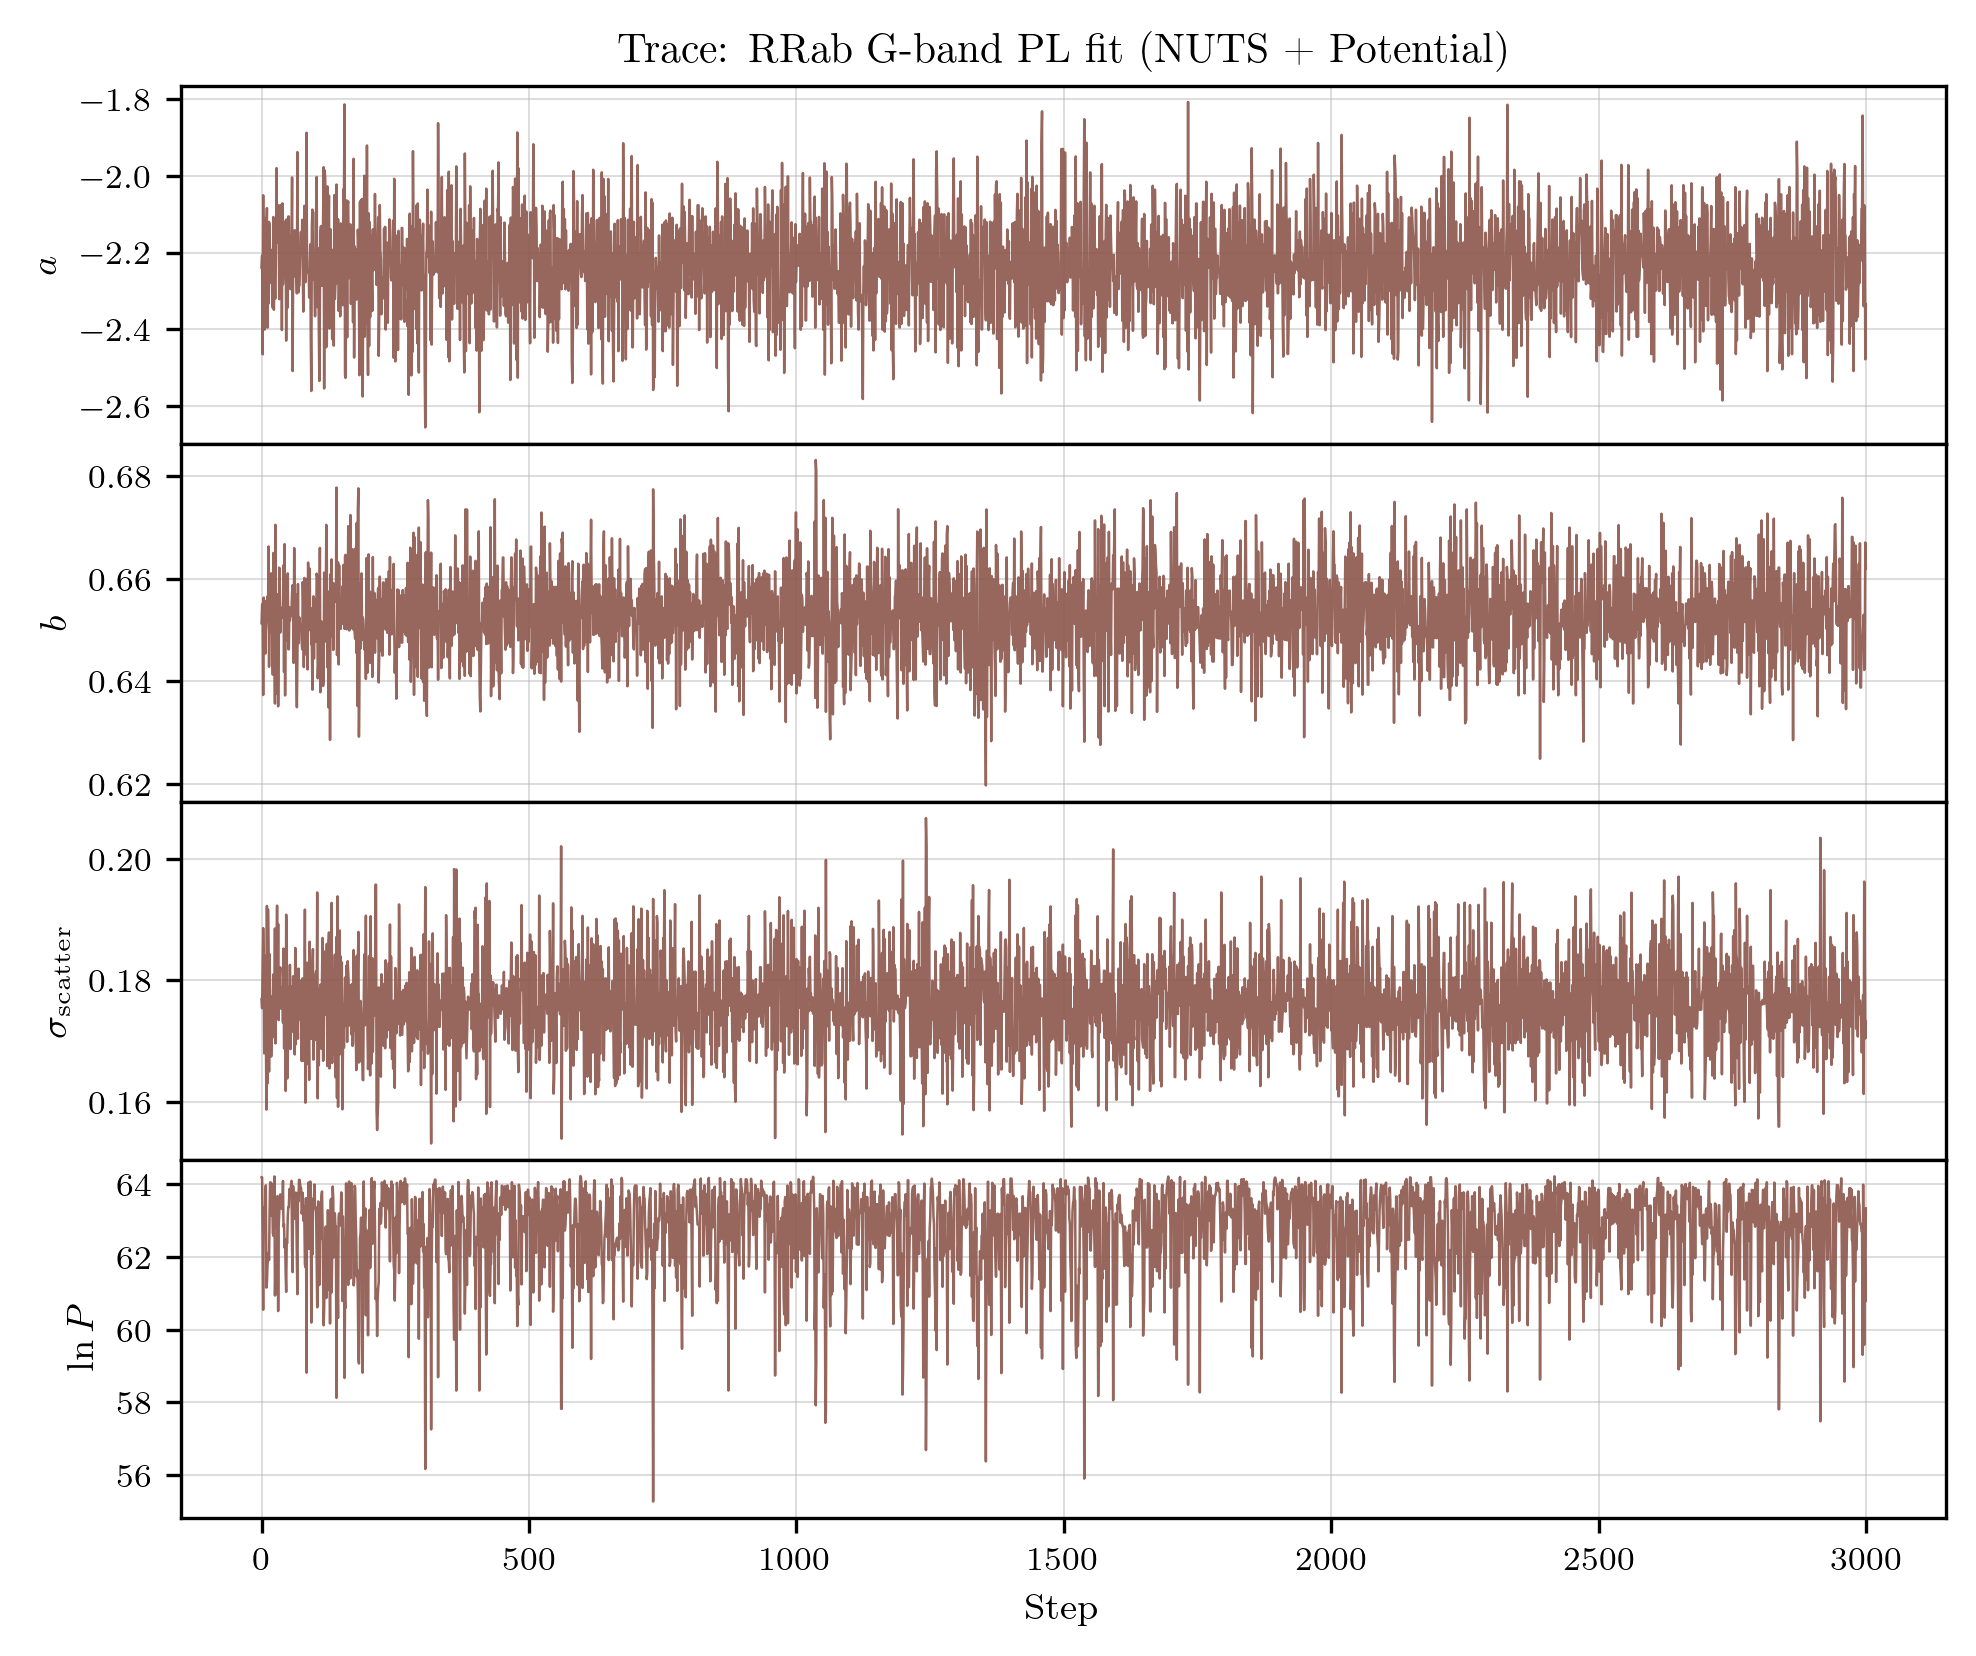

In [10]:
axes = plot_trace(
    rrab_nuts_potential.display.samples,
    rrab_nuts_potential.display.log_probs,
    rrab_nuts_potential.display.param_labels,
    rrab_nuts_potential.display.n_burn,
    color=mcmc_sampler_color("RRab", "nuts + potential"),
)
axes[0].set_title('Trace: RRab G-band PL fit (NUTS + Potential)')
plt.show()

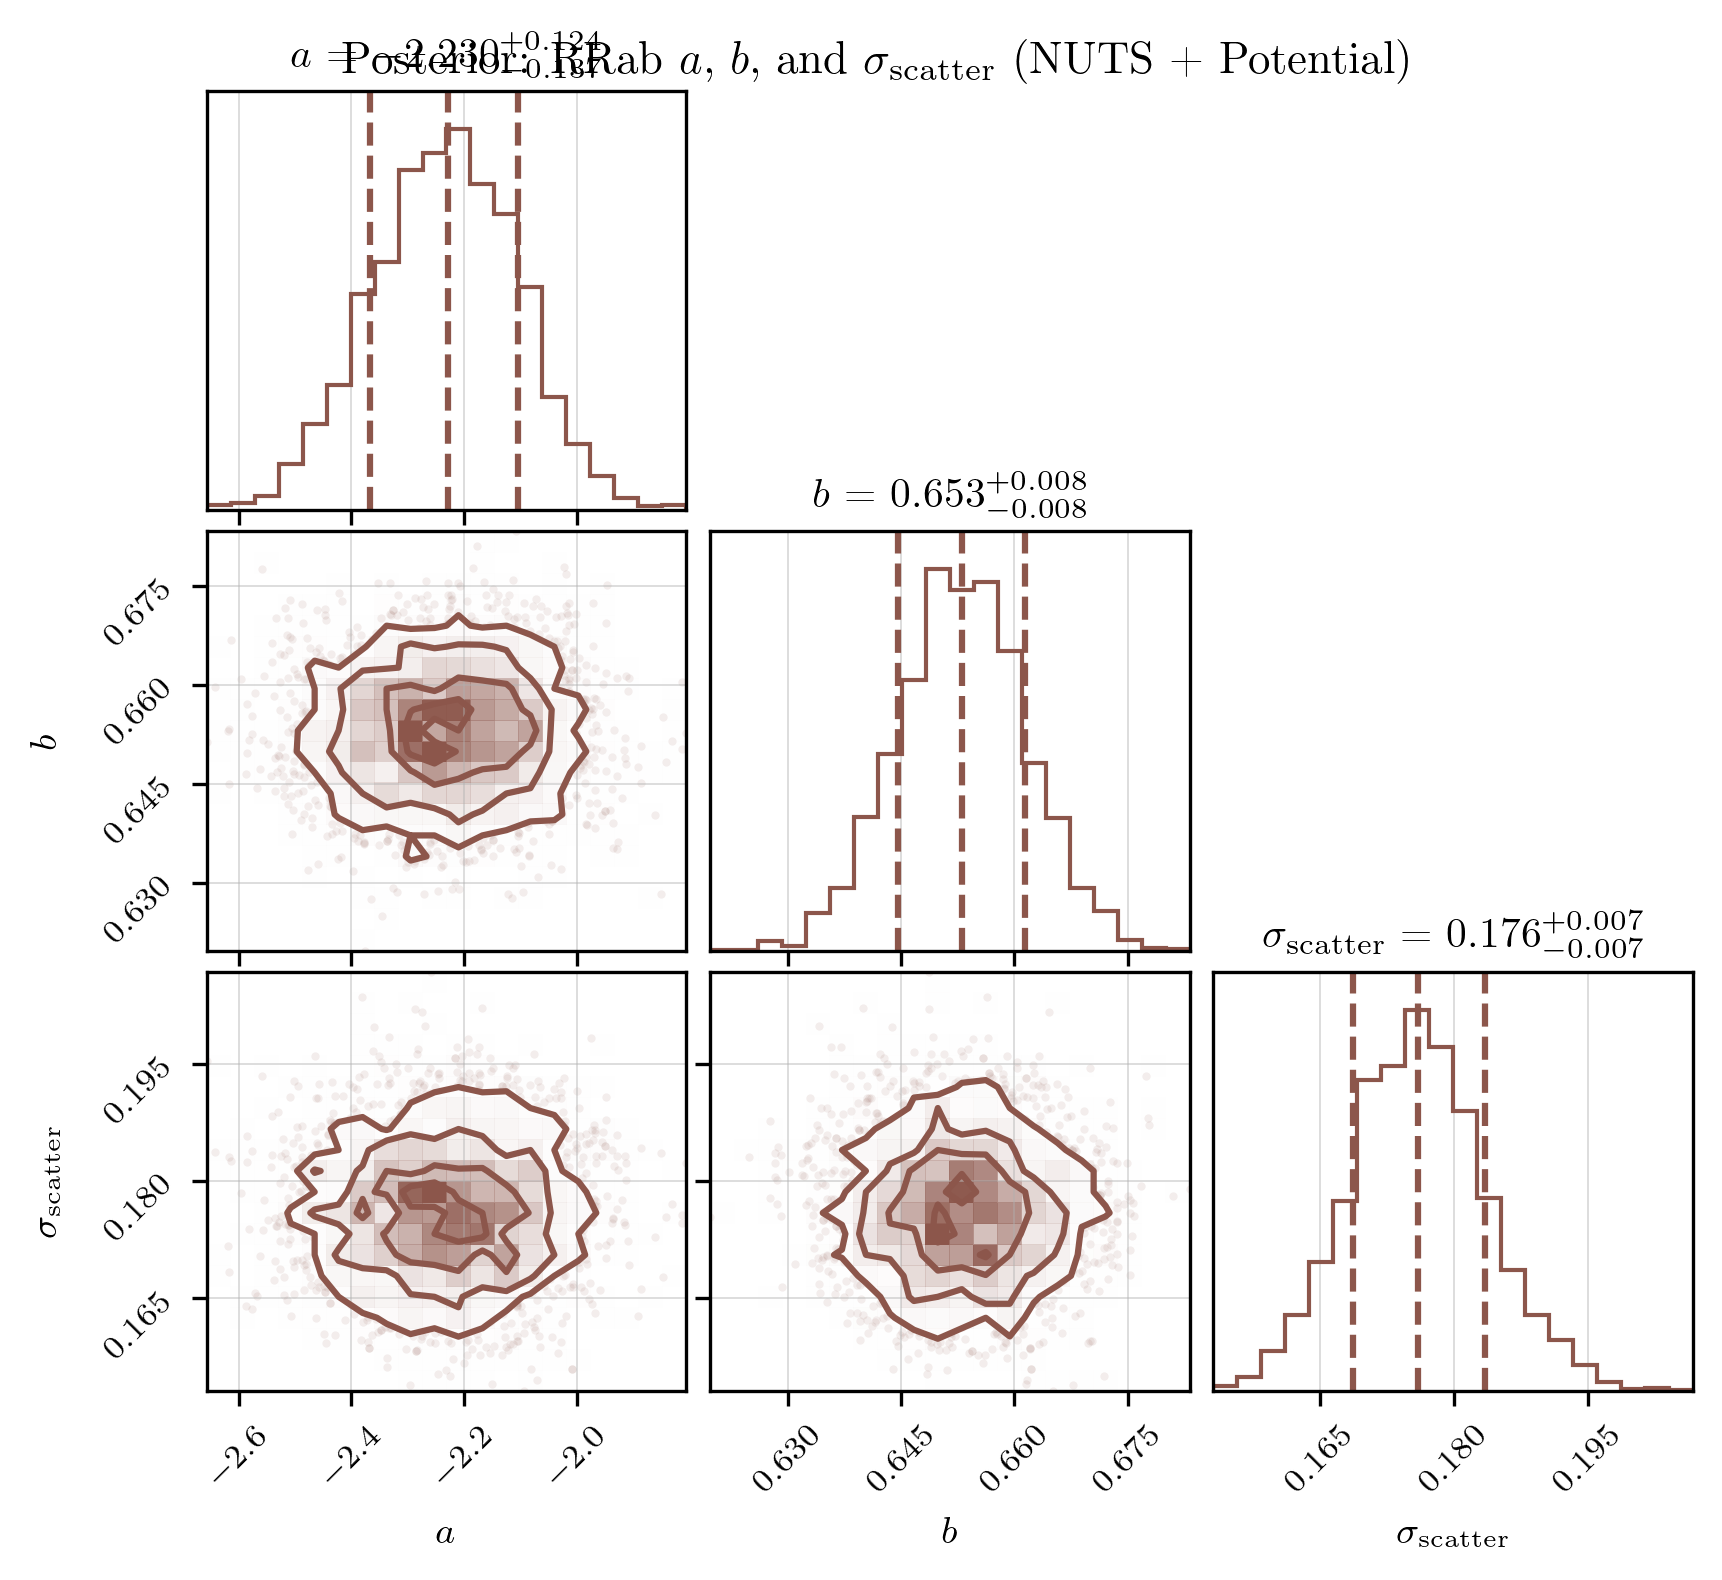

In [11]:
fig = plot_corner(
    rrab_nuts_potential.display,
    color=mcmc_sampler_color("RRab", "nuts + potential"),
    save="fig_nuts_corner.pdf",
)
fig.suptitle(r'Posterior: RRab $a$, $b$, and $\sigma_{\rm scatter}$ (NUTS + Potential)')
plt.show()

The native PyMC likelihood below is the most standard probabilistic-program expression of this model. Instead of injecting a custom log-likelihood manually, it declares the mean relation and total Gaussian width directly with `pm.Normal(..., observed=...)`. Because the statistical model is unchanged, the native NUTS run should agree with the `pm.Potential` run up to Monte Carlo noise. That agreement should be understood geometrically as well as numerically: the two NUTS implementations should recover the same posterior correlation structure, not just similar marginal medians.


In [12]:
rrab_nuts_native = fit_pl_nuts_native(rrab_ctx)
rrab_nuts_native.summary = pl_posterior_summary_row("Native PyMC NUTS", rrab_ctx.class_label, rrab_nuts_native.samples, rrab_nuts_native.acceptance_rate)
rrab_nuts_native.summary

Initializing NUTS using jitter+adapt_diag...


Sequential sampling (1 chains in 1 job)


NUTS: [a, b, sigma_scatter]


Output()

Sampling 1 chain for 1_500 tune and 3_000 draw iterations (1_500 + 3_000 draws total) took 2 seconds.


Only one chain was sampled, this makes it impossible to run some convergence checks


{'class': 'RRab',
 'method': 'Native PyMC NUTS',
 'acceptance': 0.821,
 'a': -2.2316,
 'a_minus': 0.127,
 'a_plus': 0.1295,
 'b': 0.6531,
 'b_minus': 0.0088,
 'b_plus': 0.0082,
 'sigma_scatter': 0.1762,
 'sigma_minus': 0.0076,
 'sigma_plus': 0.0077}

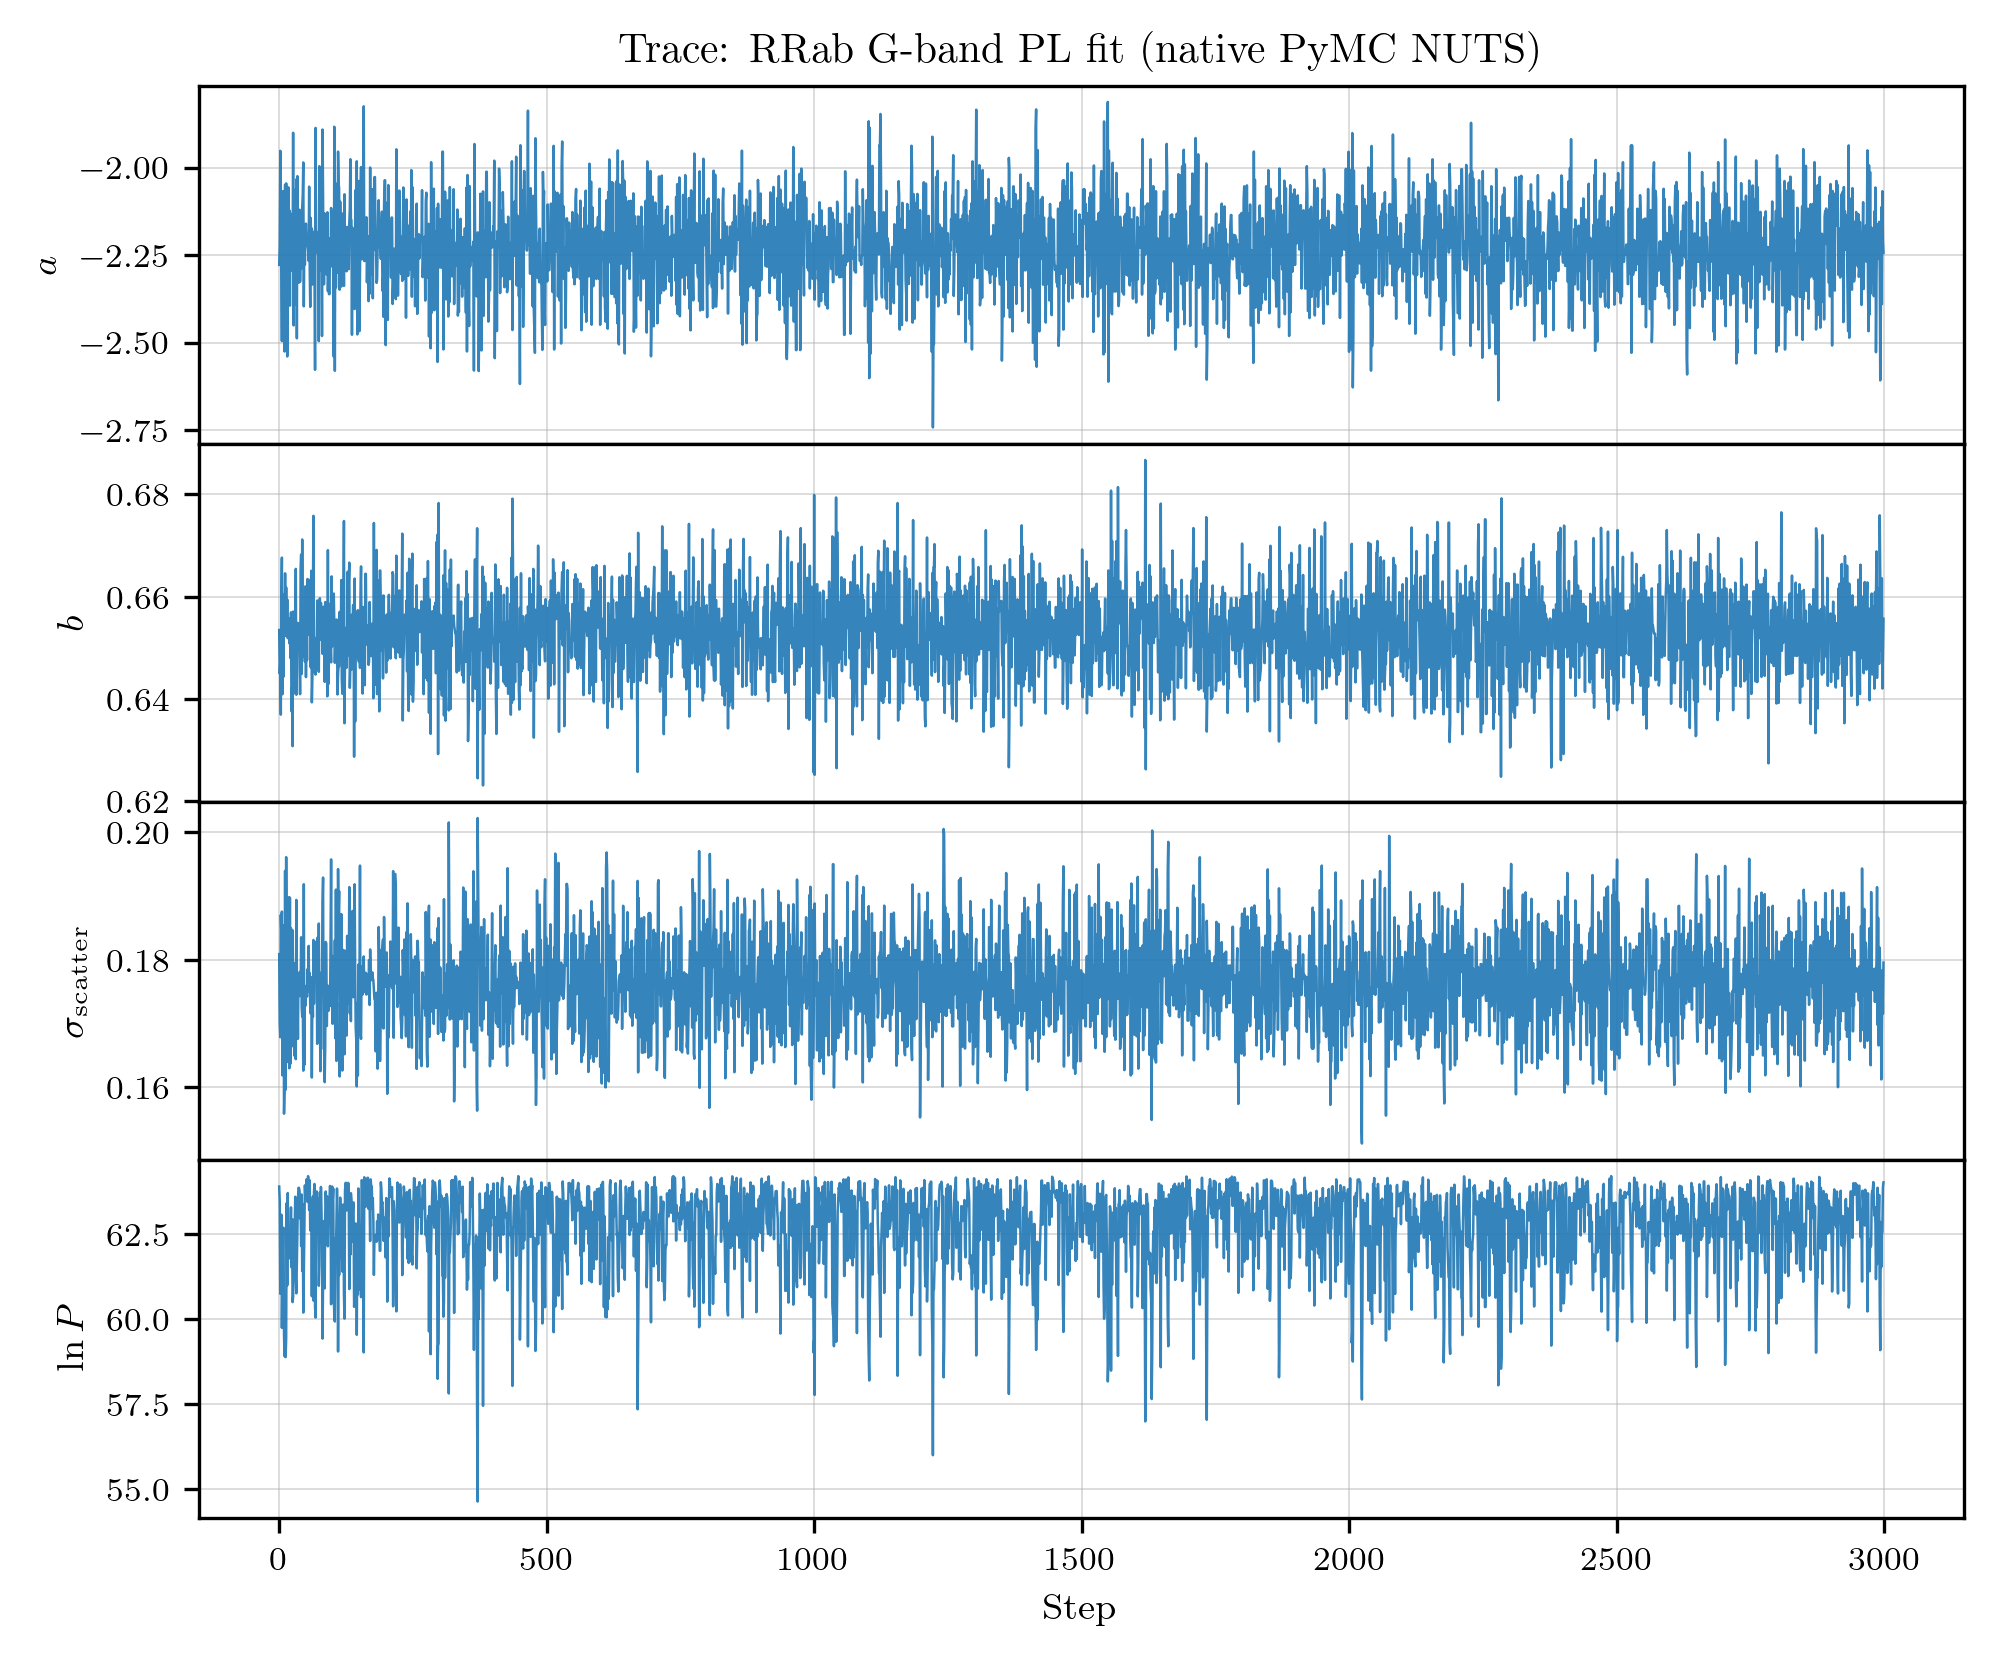

In [13]:
axes = plot_trace(
    rrab_nuts_native.display.samples,
    rrab_nuts_native.display.log_probs,
    rrab_nuts_native.display.param_labels,
    rrab_nuts_native.display.n_burn,
    color=mcmc_sampler_color("RRab", "native"),
)
axes[0].set_title('Trace: RRab G-band PL fit (native PyMC NUTS)')
plt.show()

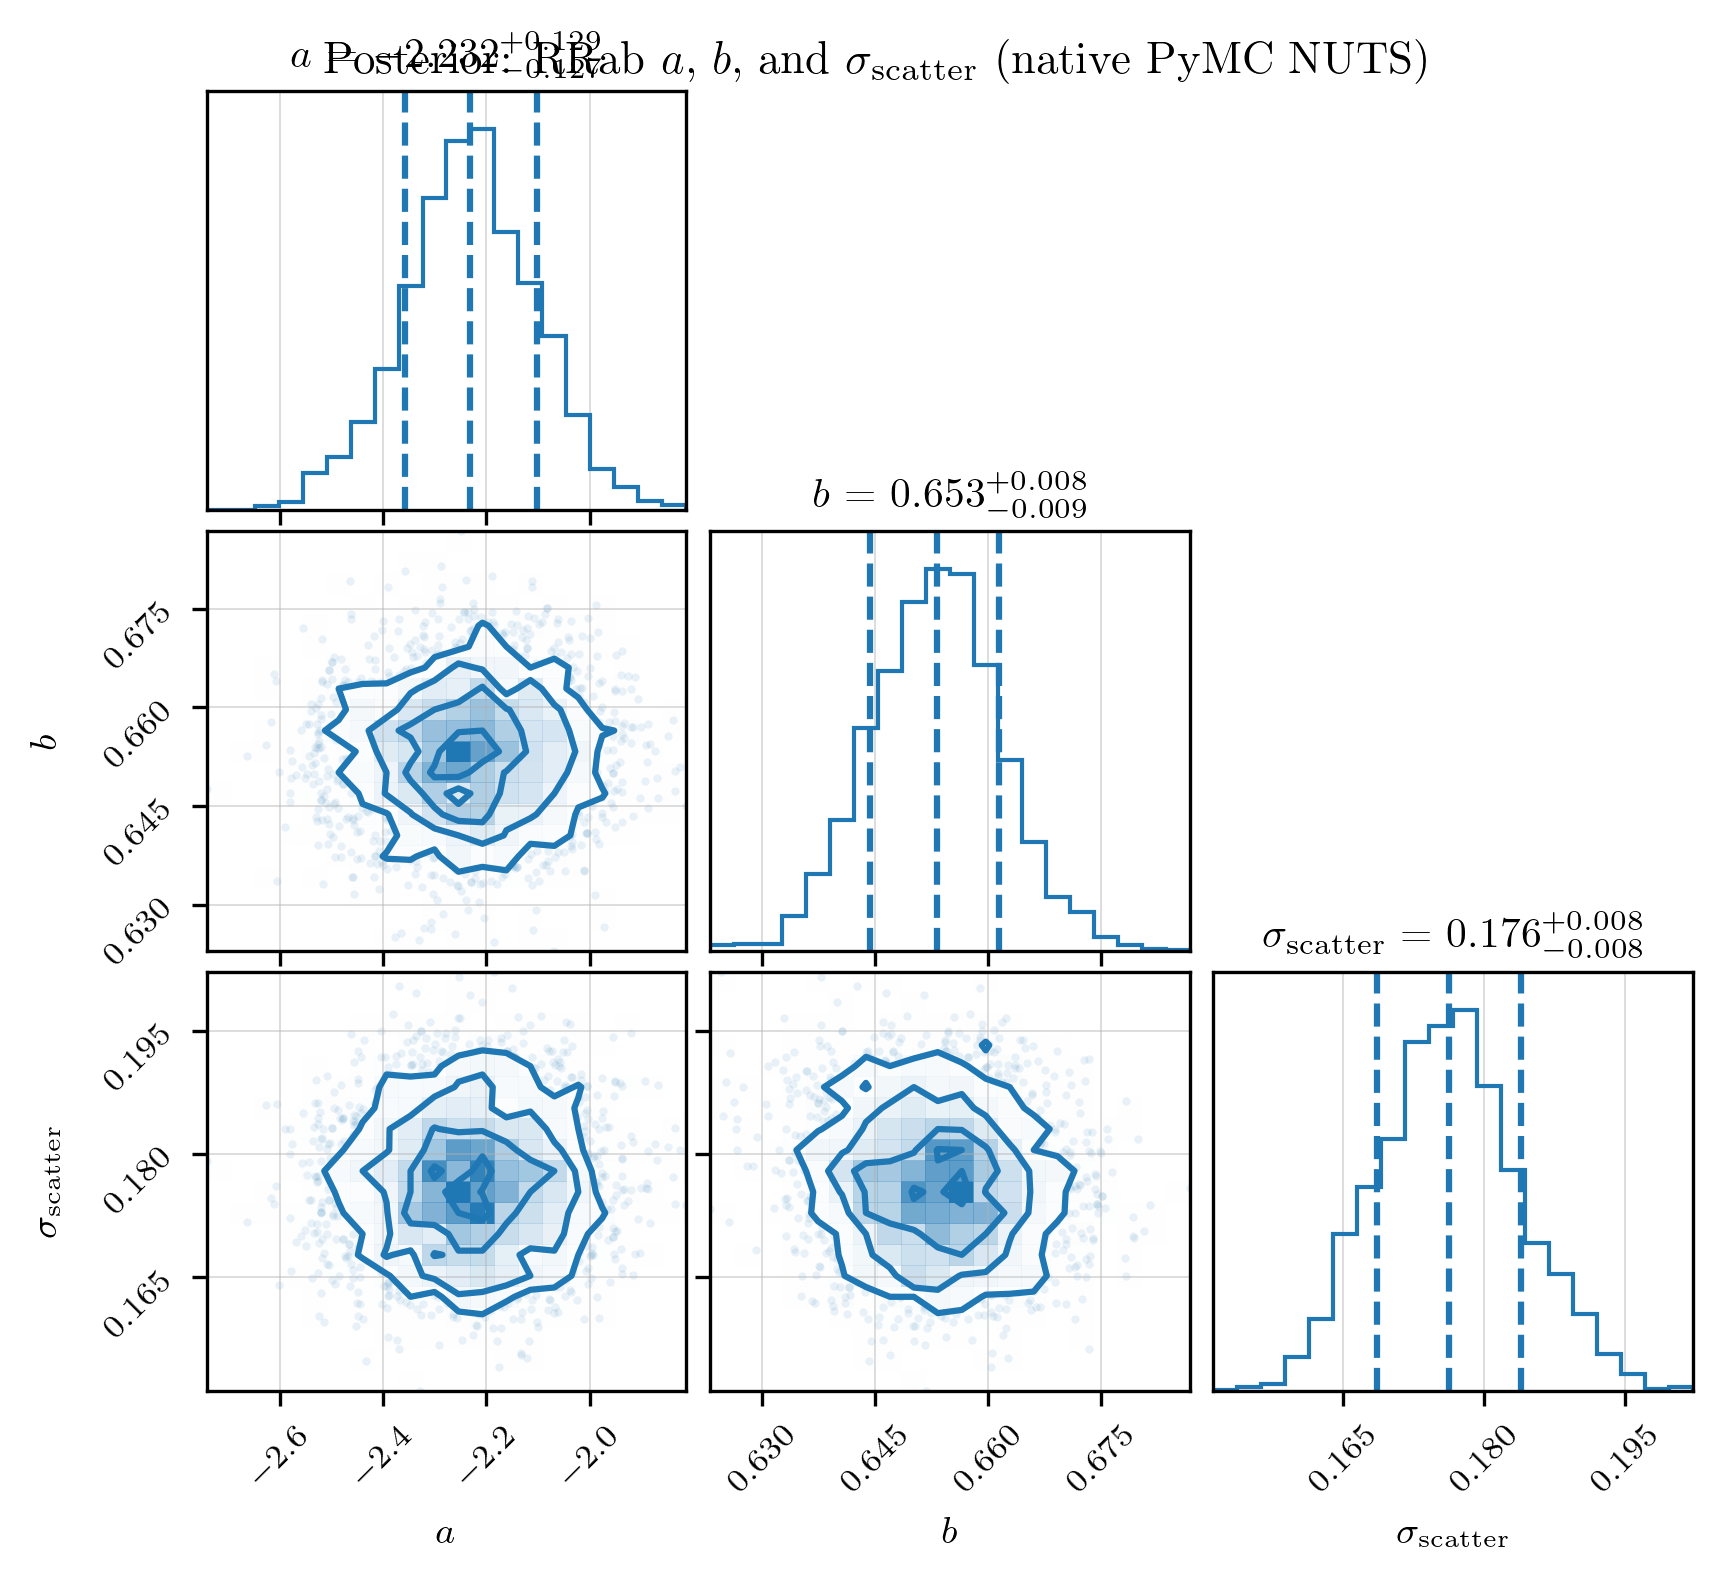

In [14]:
fig = plot_corner(
    rrab_nuts_native.display,
    color=mcmc_sampler_color("RRab", "native"),
    save="fig_native_corner.pdf",
)
fig.suptitle(r'Posterior: RRab $a$, $b$, and $\sigma_{\rm scatter}$ (native PyMC NUTS)')
plt.show()

In [15]:
rrab_summary = table.Table(rows=[rrab_mh.summary, rrab_nuts_potential.summary, rrab_nuts_native.summary])
rrab_summary


class,method,acceptance,a,a_minus,a_plus,b,b_minus,b_plus,sigma_scatter,sigma_minus,sigma_plus
str4,str19,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
RRab,Metropolis-Hastings,0.549,-2.2657,0.1343,0.1145,0.6531,0.009,0.0089,0.1761,0.0073,0.0074
RRab,NUTS + Potential,0.838,-2.2296,0.1366,0.1239,0.653,0.0085,0.0084,0.176,0.0073,0.0075
RRab,Native PyMC NUTS,0.821,-2.2316,0.127,0.1295,0.6531,0.0088,0.0082,0.1762,0.0076,0.0077


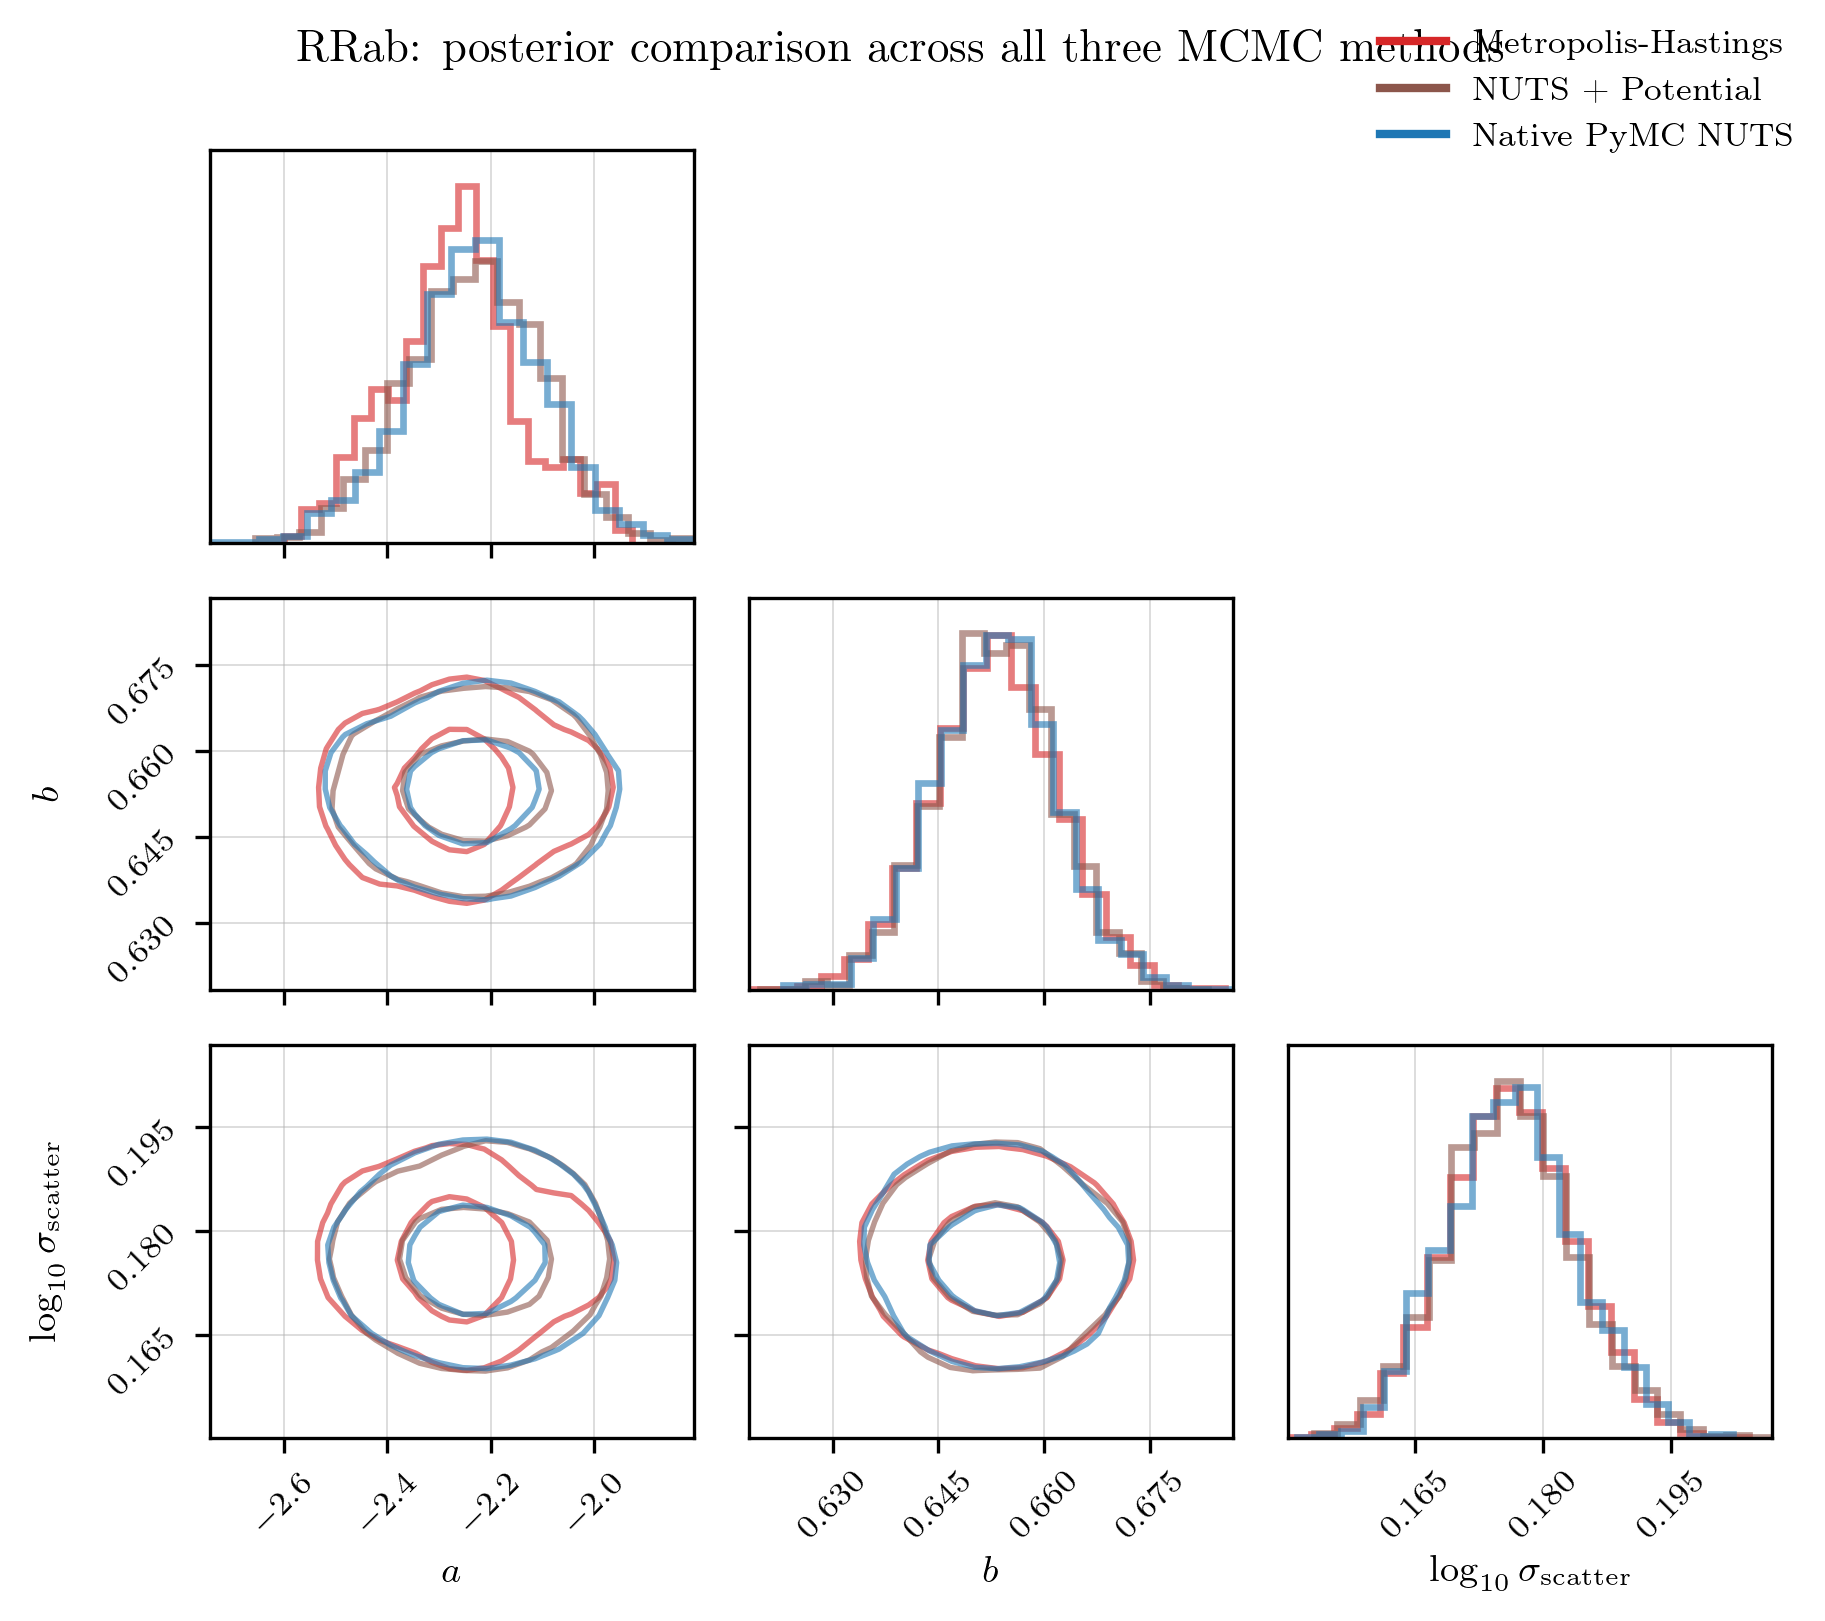

In [16]:
fig = plot_pl_sampler_comparison_corner(
    {
        "Metropolis-Hastings": rrab_mh.display.samples[rrab_mh.display.n_burn:],
        "NUTS + Potential": rrab_nuts_potential.display.samples[rrab_nuts_potential.display.n_burn:],
        "Native PyMC NUTS": rrab_nuts_native.display.samples[rrab_nuts_native.display.n_burn:],
    },
    class_label="RRab",
    save_name="fig_methods_corner_rrab.pdf",
)
fig.suptitle(r"RRab: posterior comparison across all three MCMC methods", y=1.01)
plt.show()

The posterior predictive figure below is a full predictive diagnostic, not just a plot of uncertainty in the mean relation. The shaded envelopes combine three ingredients: the quoted absolute-magnitude uncertainty, the propagated period term, and the inferred intrinsic scatter. Agreement between the data cloud and these envelopes therefore tests whether the model describes the observed width of the RRab relation, not merely whether the posterior median line passes through the center. But a good predictive envelope does not by itself certify that the chain mixed efficiently; predictive fit and MCMC diagnostics answer different questions.

The additional line-sample plot below restores the handout's original visualization request: 50 random posterior mean relations drawn over the data. Unlike the predictive envelope, those lines do **not** include the intrinsic-scatter or observational-width term; they only show the posterior uncertainty in the mean relation itself.

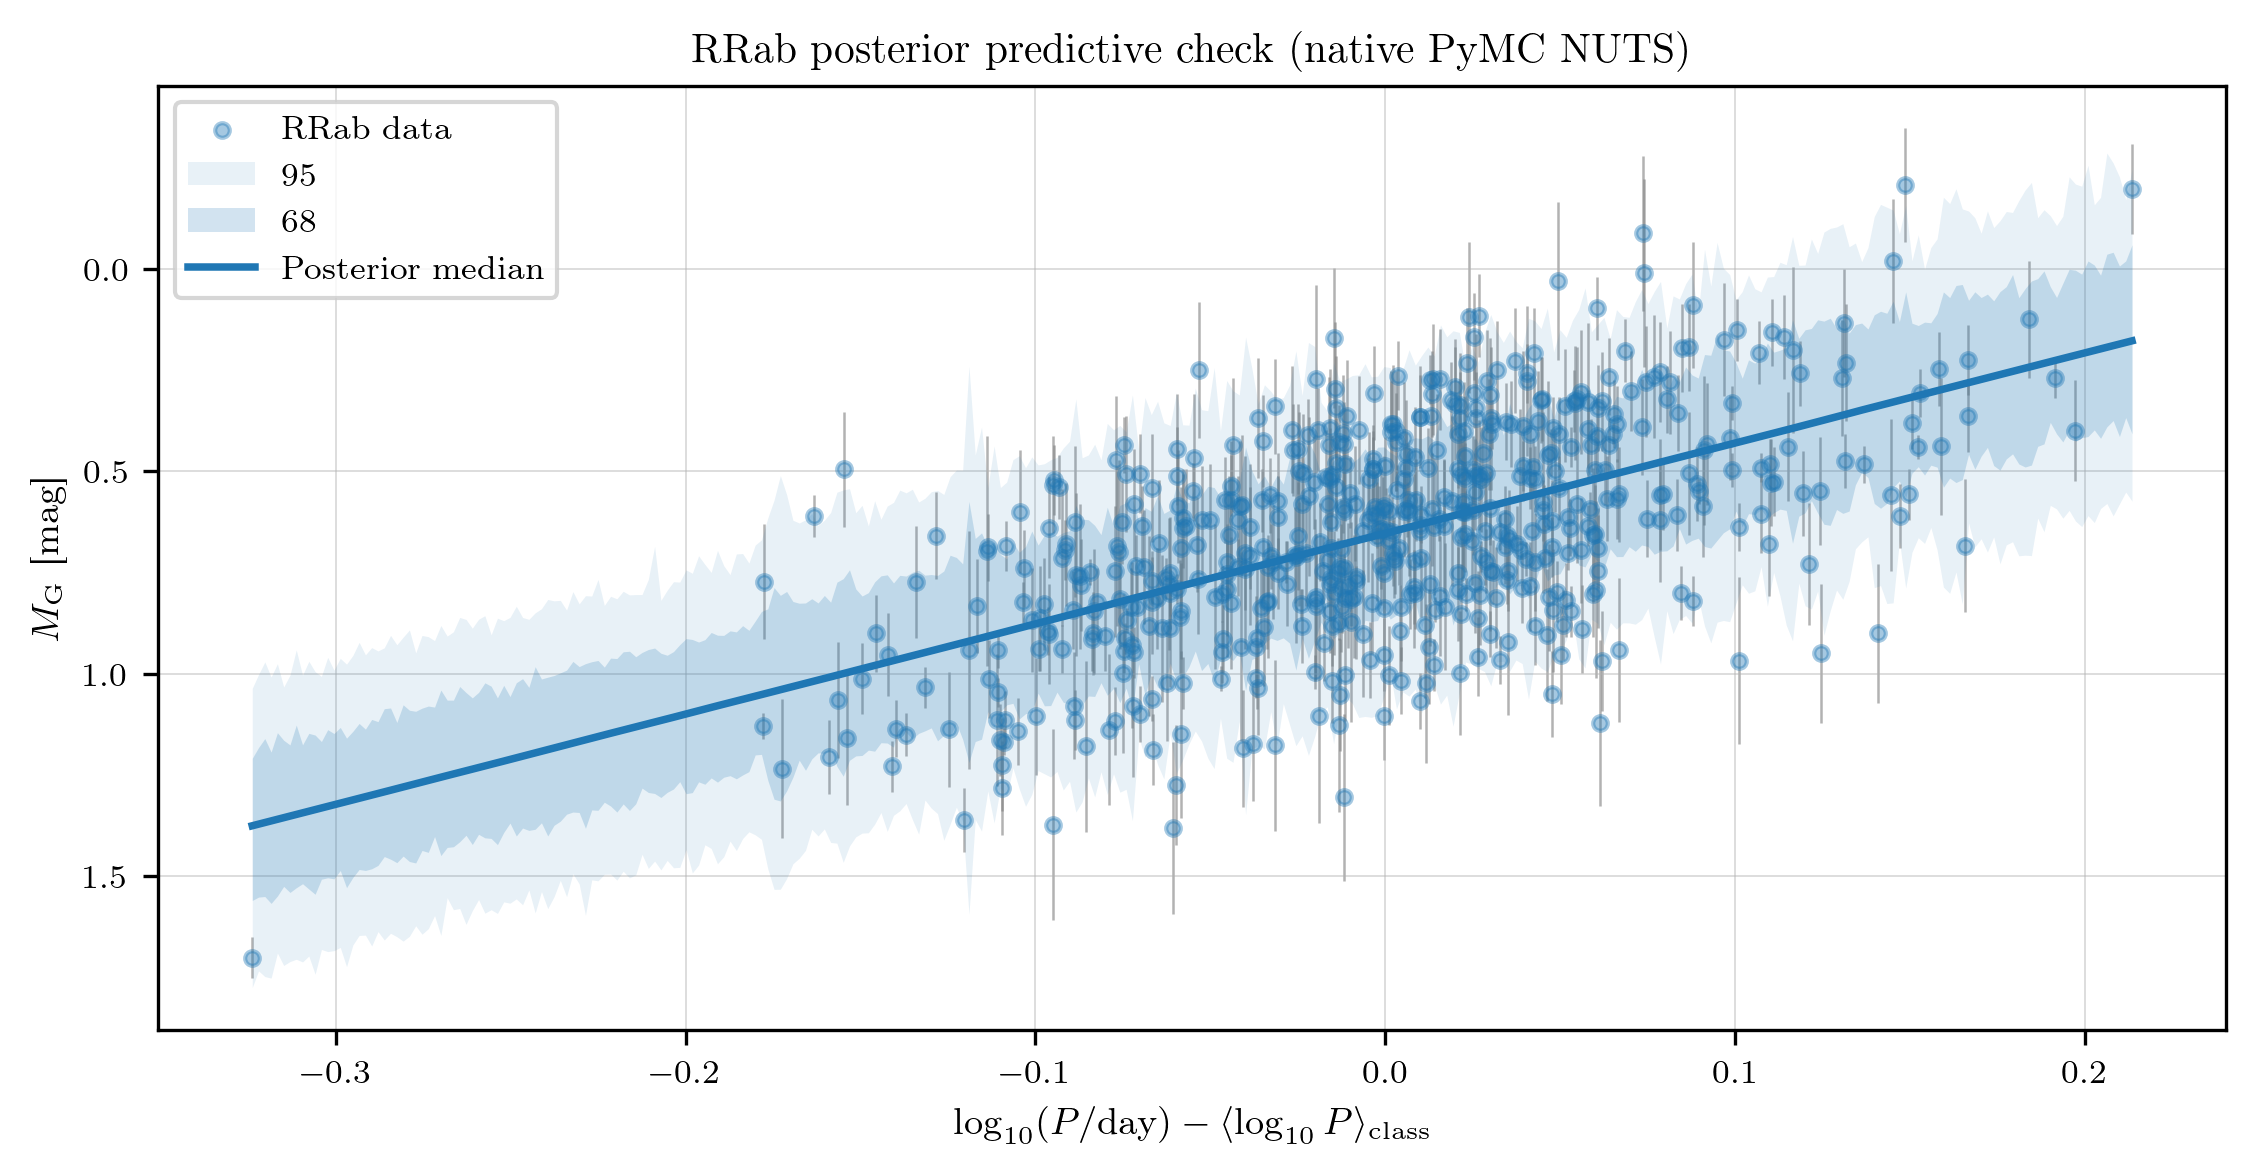

In [17]:
ax = plot_pl_posterior_predictive(
    rrab_ctx,
    rrab_nuts_native.samples[rrab_nuts_native.display.n_burn:],
    save="fig_pl_posterior.pdf",
)
ax.set_title('RRab posterior predictive check (native PyMC NUTS)')
plt.show()

## RRc Fit

RRc stars are first-overtone RR Lyrae pulsators. This section mirrors the RRab analysis with the RRc-only subset.


In [18]:
rrc_proposal_scan = proposal_scan(rrc_ctx)
rrc_proposal_std = np.array(
    min(rrc_proposal_scan, key=lambda row: abs(float(row["acceptance"]) - 0.5))["proposal_std"],
    dtype=float,
)
rrc_proposal_scan


class,proposal_std,acceptance
str3,float64[3],float64
RRc,0.004 .. 0.008,0.727
RRc,0.005 .. 0.01,0.669
RRc,0.006 .. 0.012,0.609
RRc,0.008 .. 0.016,0.513
RRc,0.01 .. 0.02,0.424


From the RRc proposal scan above, I choose the scale whose acceptance fraction is closest to the pedagogical target of order $0.5$ for the final Metropolis-Hastings run. As in RRab, that number is only a tuning aid for the random-walk sampler, not a stand-alone convergence argument.


The RRc proposal scan is interpreted in the same way as the RRab scan: it is a pedagogical tuning step for the random-walk MH branch only. The goal is not to optimize some globally correct acceptance fraction, but to avoid obviously pathological proposals before comparing the resulting posterior to the NUTS runs. The real diagnostic question is whether the trace avoids long sticky plateaus and whether the posterior geometry agrees with the NUTS solutions.


In [19]:
rrc_mh = run_mh_fit(rrc_ctx, rrc_proposal_std)
rrc_mh.summary


{'class': 'RRc',
 'method': 'Metropolis-Hastings',
 'acceptance': 0.53,
 'a': -2.2082,
 'a_minus': 0.1836,
 'a_plus': 0.1684,
 'b': 0.5734,
 'b_minus': 0.0112,
 'b_plus': 0.0117,
 'sigma_scatter': 0.1681,
 'sigma_minus': 0.0088,
 'sigma_plus': 0.0093}

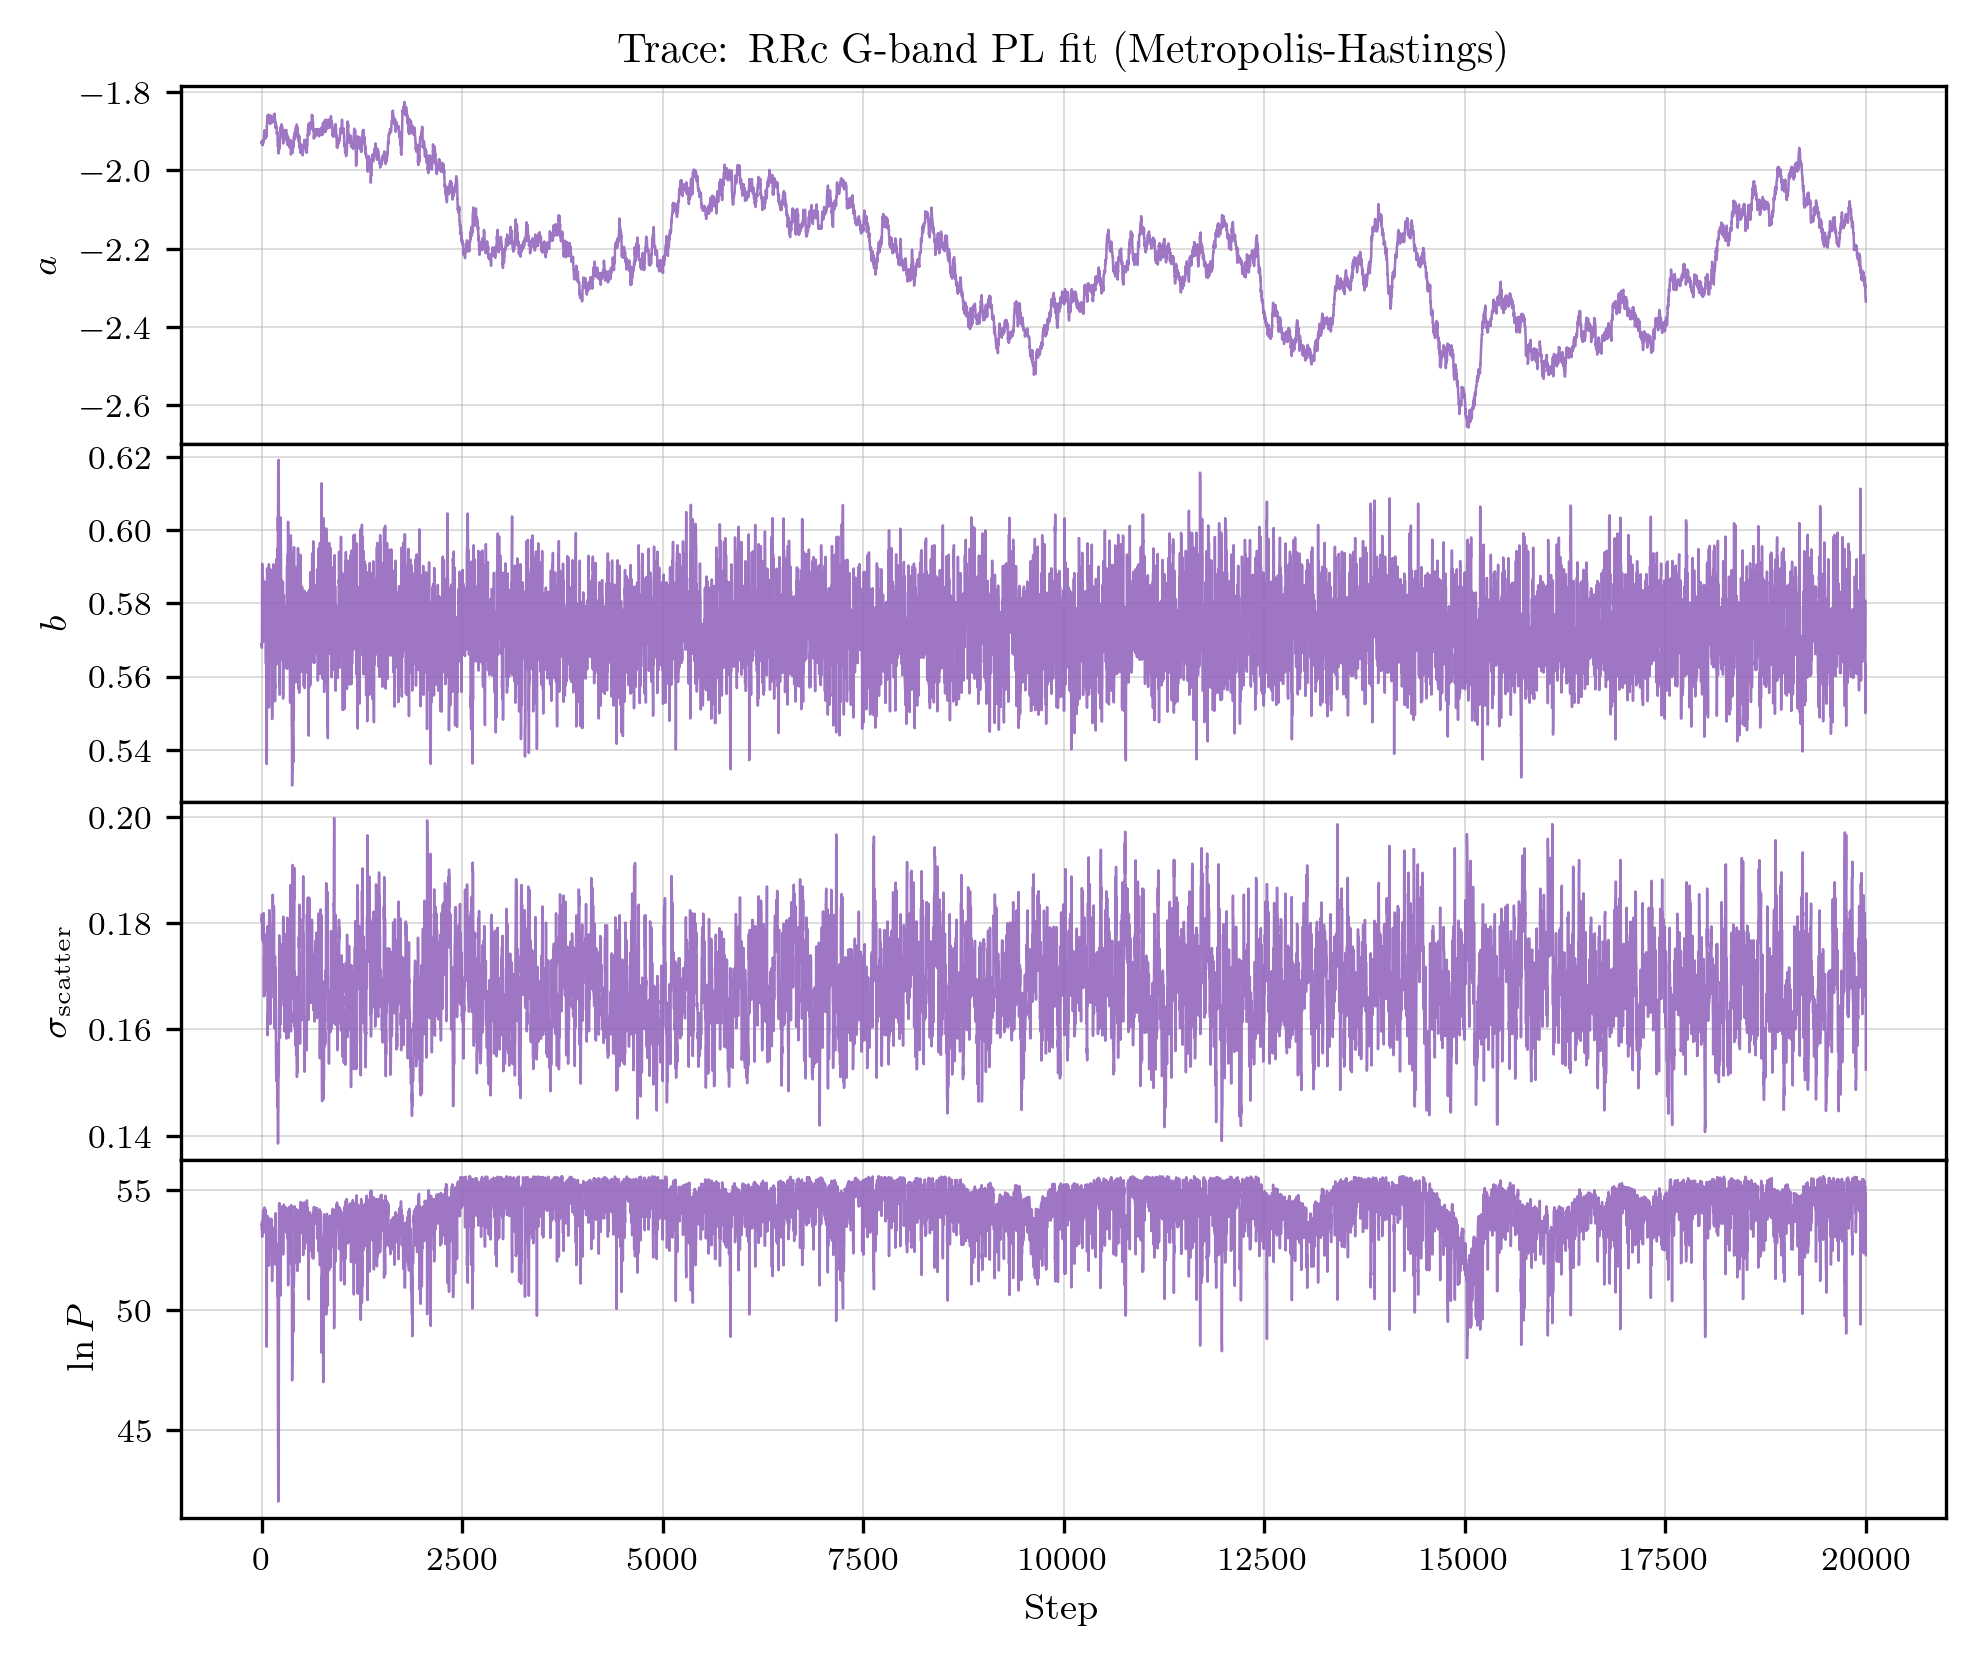

In [20]:
axes = plot_trace(
    rrc_mh.display.samples,
    rrc_mh.display.log_probs,
    rrc_mh.display.param_labels,
    rrc_mh.display.n_burn,
    color=mcmc_sampler_color("RRc", "mh"),
)
axes[0].set_title('Trace: RRc G-band PL fit (Metropolis-Hastings)')
plt.show()

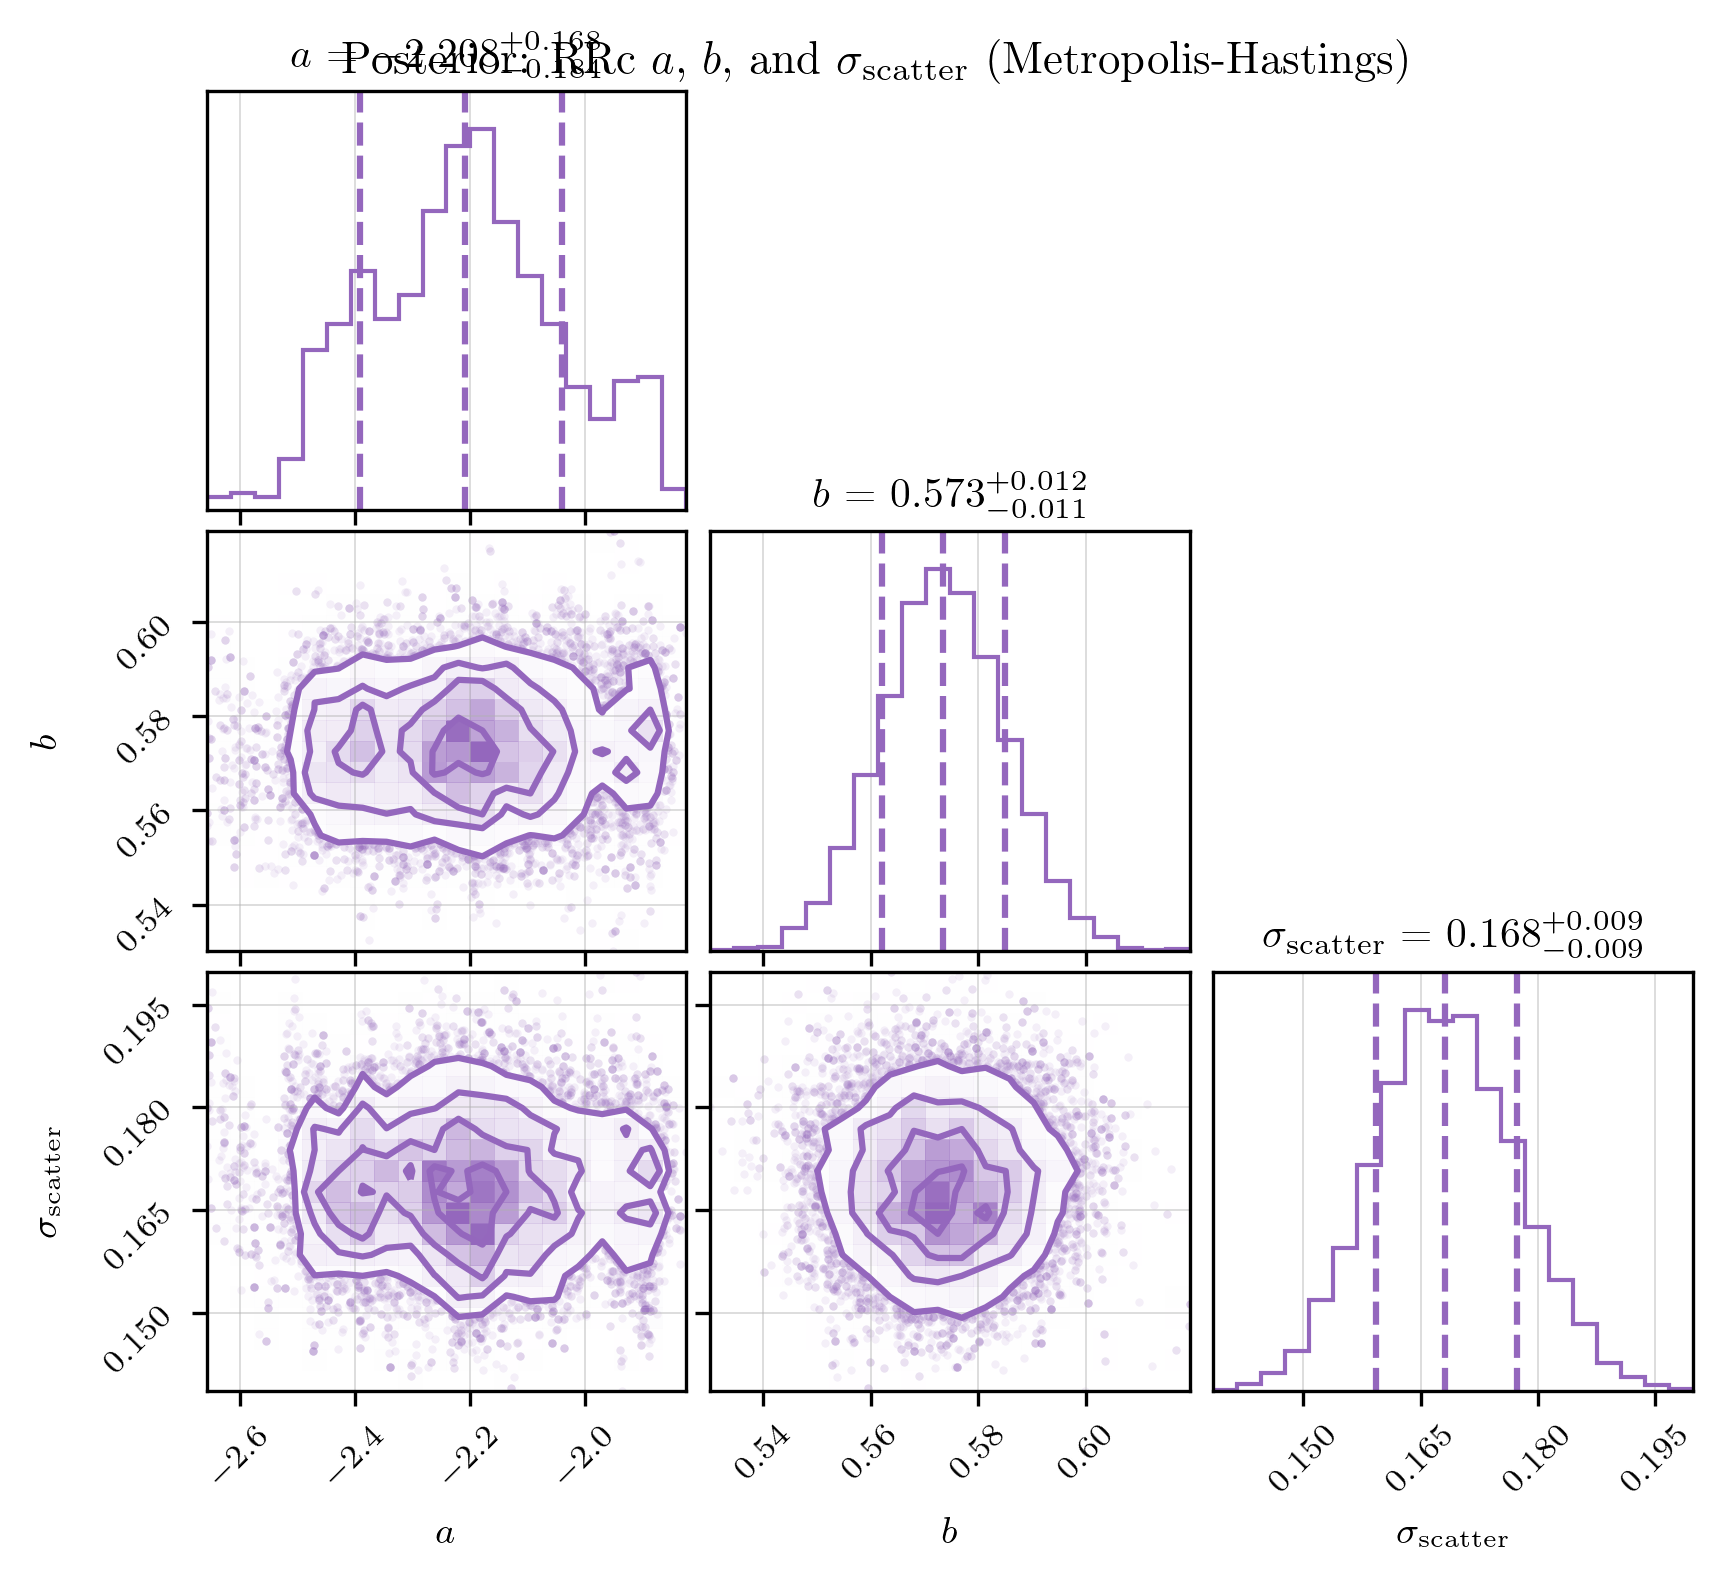

In [21]:
fig = plot_corner(
    rrc_mh.display,
    color=mcmc_sampler_color("RRc", "mh"),
)
fig.suptitle(r'Posterior: RRc $a$, $b$, and $\sigma_{\rm scatter}$ (Metropolis-Hastings)')
plt.show()

In [22]:
rrc_nuts_potential = fit_pl_nuts_potential(rrc_ctx)
rrc_nuts_potential.summary = pl_posterior_summary_row("NUTS + Potential", rrc_ctx.class_label, rrc_nuts_potential.samples, rrc_nuts_potential.acceptance_rate)
rrc_nuts_potential.summary

Initializing NUTS using jitter+adapt_diag...


Sequential sampling (1 chains in 1 job)


NUTS: [a, b, sigma_scatter]


Output()

Sampling 1 chain for 1_500 tune and 3_000 draw iterations (1_500 + 3_000 draws total) took 1 seconds.


Only one chain was sampled, this makes it impossible to run some convergence checks


{'class': 'RRc',
 'method': 'NUTS + Potential',
 'acceptance': 0.837,
 'a': -2.1926,
 'a_minus': 0.177,
 'a_plus': 0.1818,
 'b': 0.5734,
 'b_minus': 0.0111,
 'b_plus': 0.0111,
 'sigma_scatter': 0.1683,
 'sigma_minus': 0.0094,
 'sigma_plus': 0.0094}

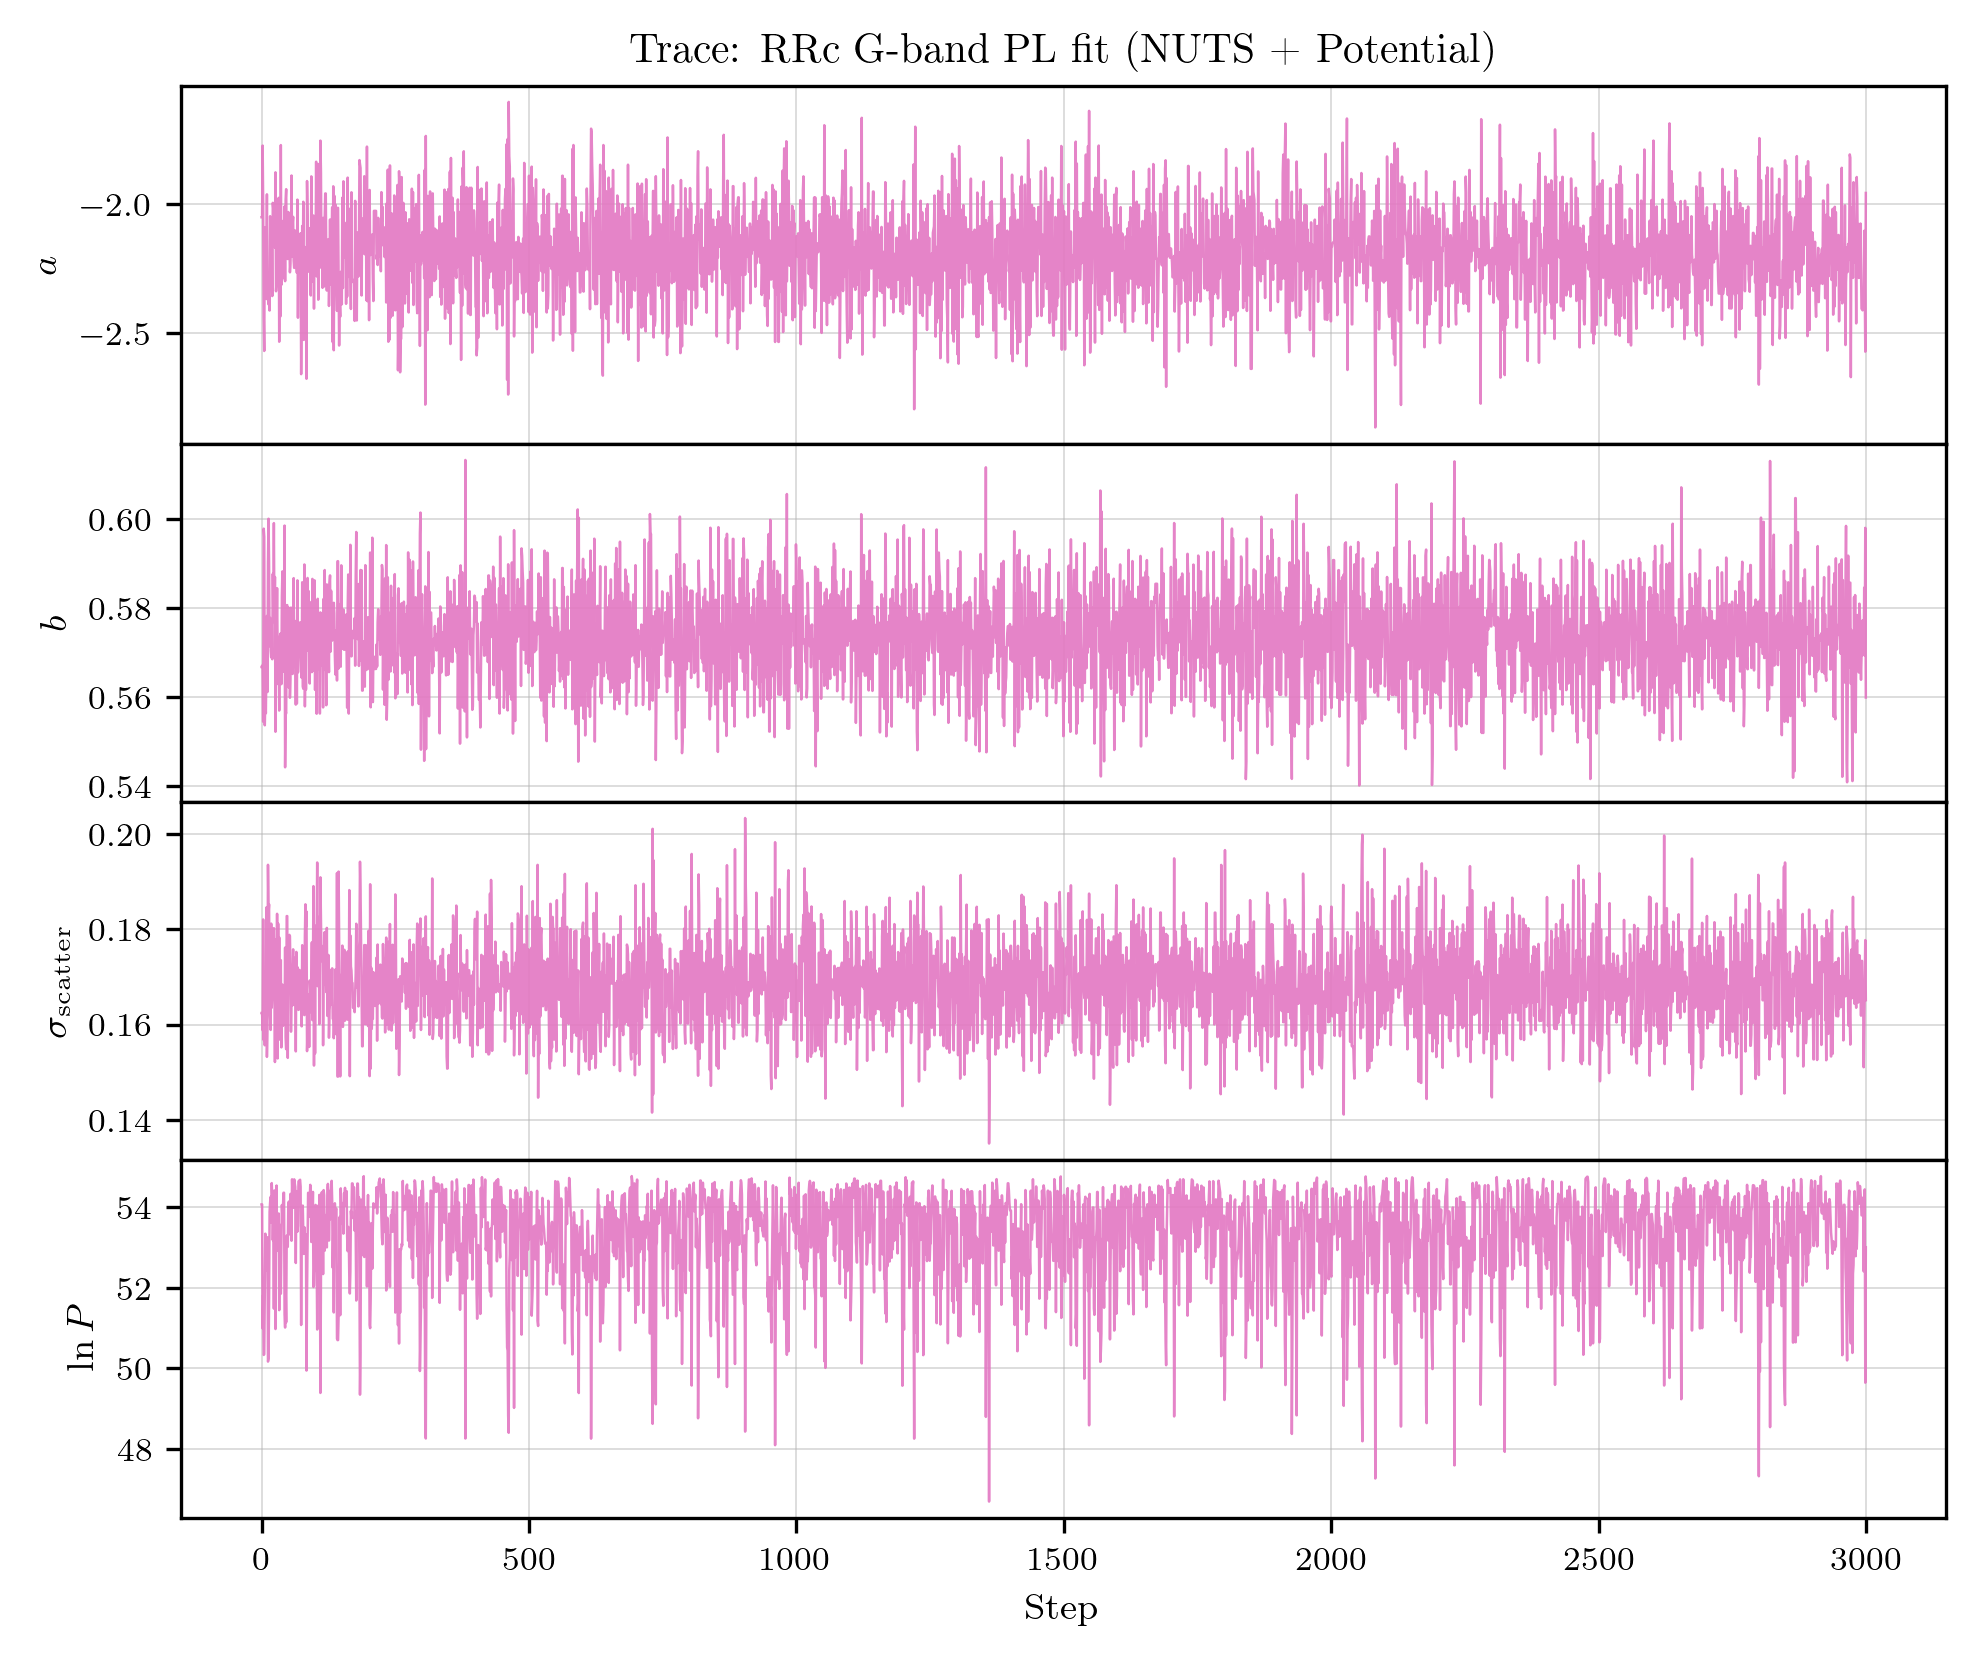

In [23]:
axes = plot_trace(
    rrc_nuts_potential.display.samples,
    rrc_nuts_potential.display.log_probs,
    rrc_nuts_potential.display.param_labels,
    rrc_nuts_potential.display.n_burn,
    color=mcmc_sampler_color("RRc", "nuts + potential"),
)
axes[0].set_title('Trace: RRc G-band PL fit (NUTS + Potential)')
plt.show()

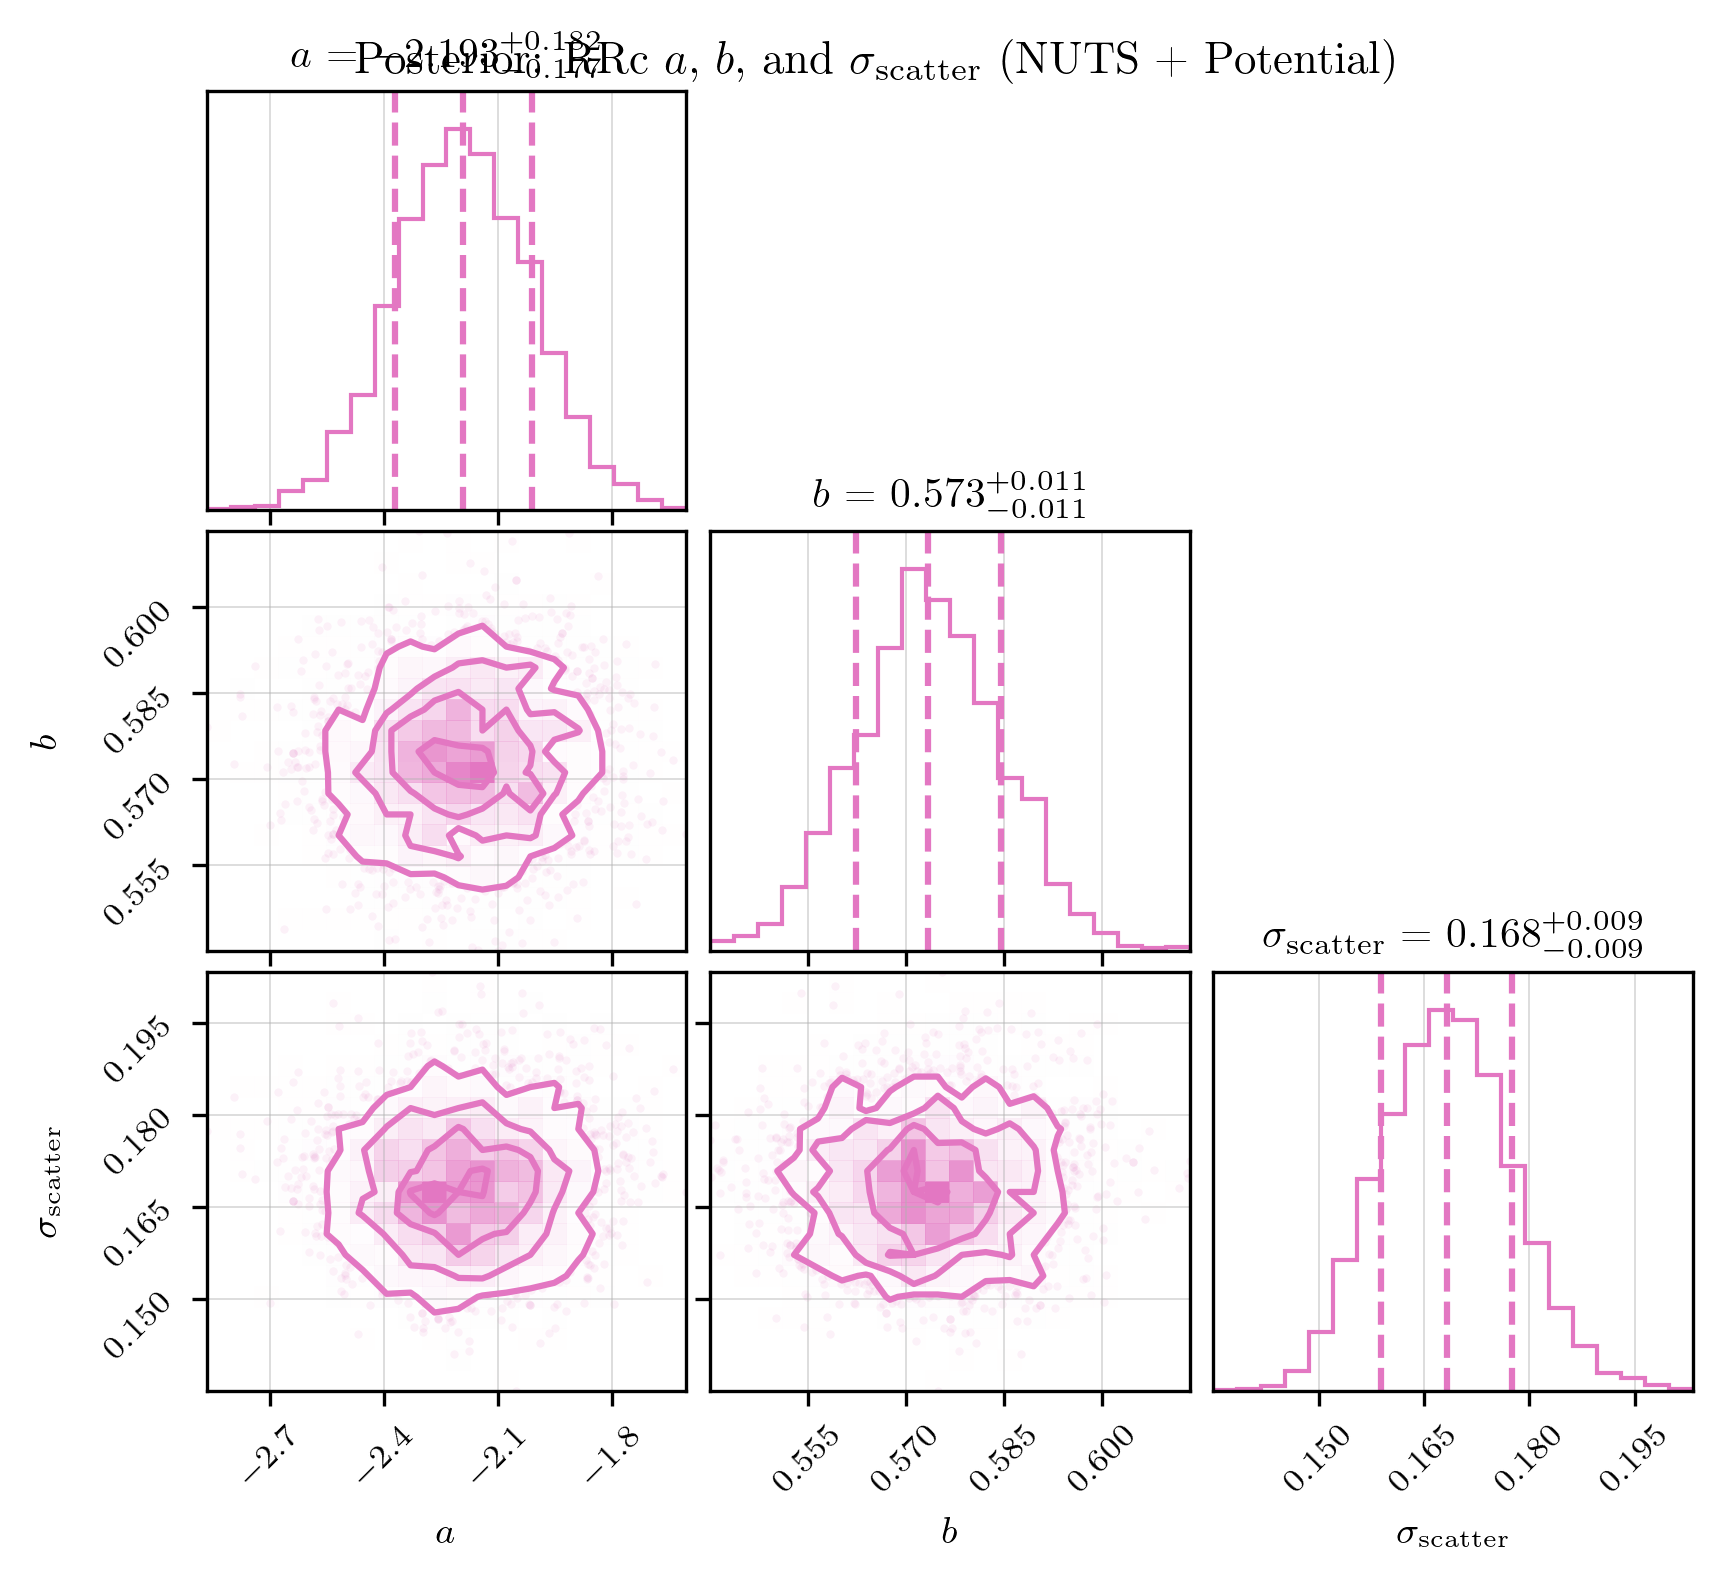

In [24]:
fig = plot_corner(
    rrc_nuts_potential.display,
    color=mcmc_sampler_color("RRc", "nuts + potential"),
)
fig.suptitle(r'Posterior: RRc $a$, $b$, and $\sigma_{\rm scatter}$ (NUTS + Potential)')
plt.show()

In [25]:
rrc_nuts_native = fit_pl_nuts_native(rrc_ctx)
rrc_nuts_native.summary = pl_posterior_summary_row("Native PyMC NUTS", rrc_ctx.class_label, rrc_nuts_native.samples, rrc_nuts_native.acceptance_rate)
rrc_nuts_native.summary

Initializing NUTS using jitter+adapt_diag...


Sequential sampling (1 chains in 1 job)


NUTS: [a, b, sigma_scatter]


Output()

Sampling 1 chain for 1_500 tune and 3_000 draw iterations (1_500 + 3_000 draws total) took 1 seconds.


Only one chain was sampled, this makes it impossible to run some convergence checks


{'class': 'RRc',
 'method': 'Native PyMC NUTS',
 'acceptance': 0.839,
 'a': -2.184,
 'a_minus': 0.1857,
 'a_plus': 0.1746,
 'b': 0.5738,
 'b_minus': 0.0116,
 'b_plus': 0.0111,
 'sigma_scatter': 0.1676,
 'sigma_minus': 0.0089,
 'sigma_plus': 0.0099}

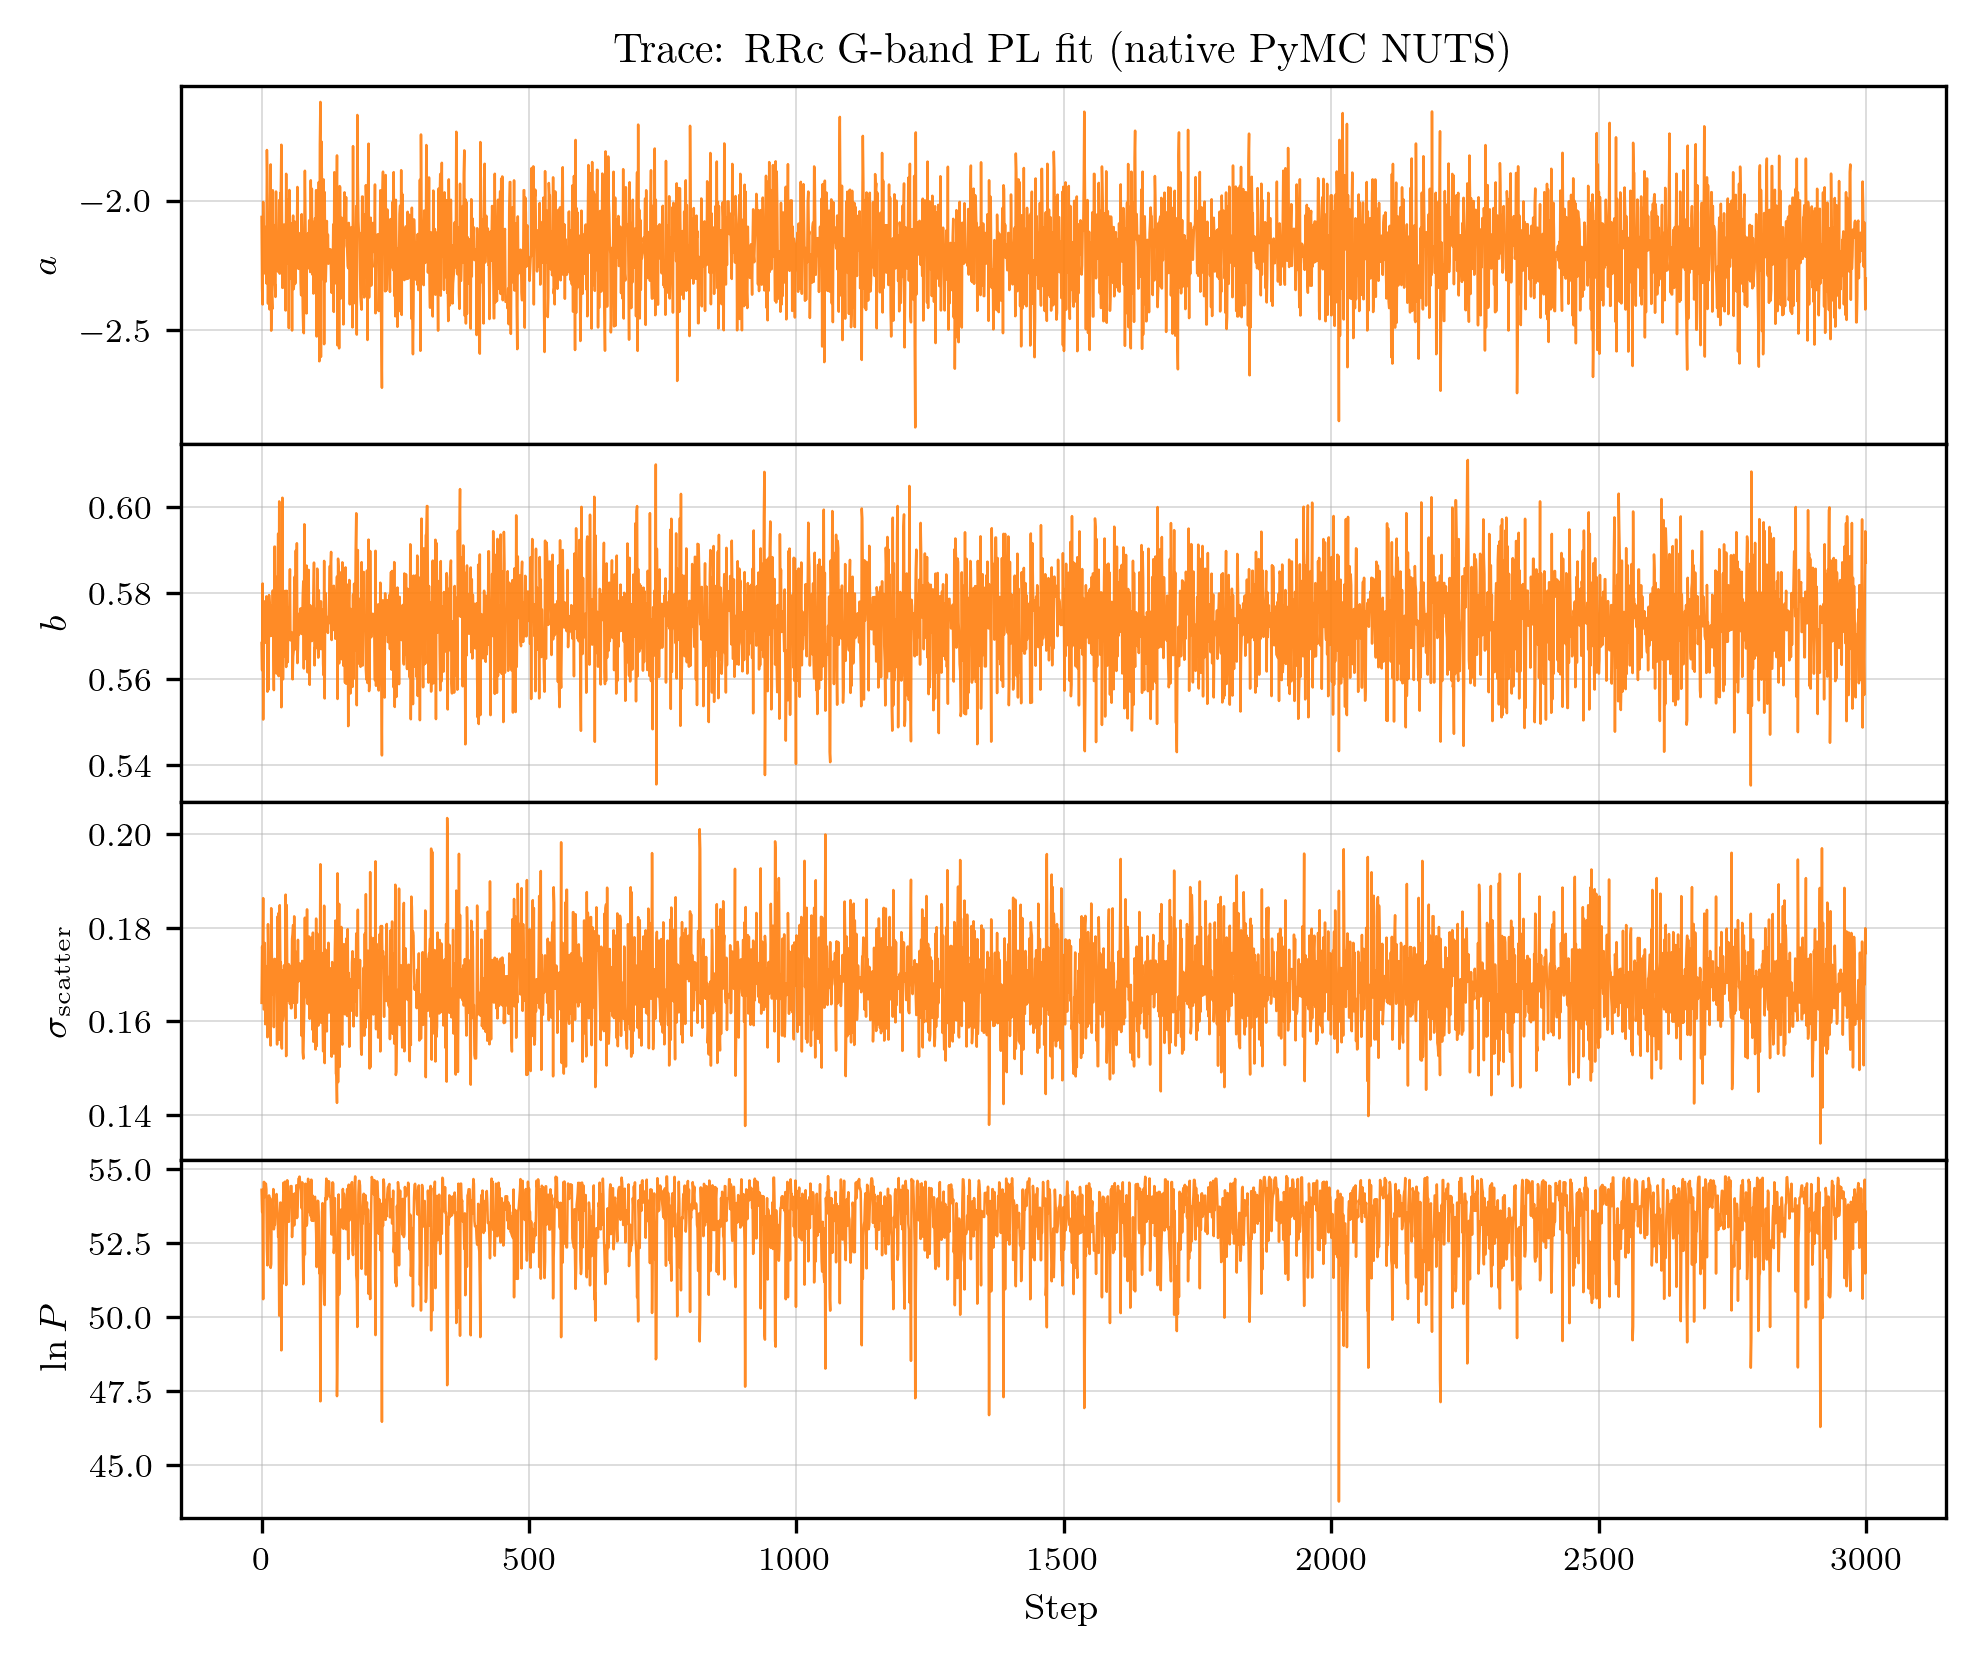

In [26]:
axes = plot_trace(
    rrc_nuts_native.display.samples,
    rrc_nuts_native.display.log_probs,
    rrc_nuts_native.display.param_labels,
    rrc_nuts_native.display.n_burn,
    color=mcmc_sampler_color("RRc", "native"),
)
axes[0].set_title('Trace: RRc G-band PL fit (native PyMC NUTS)')
plt.show()

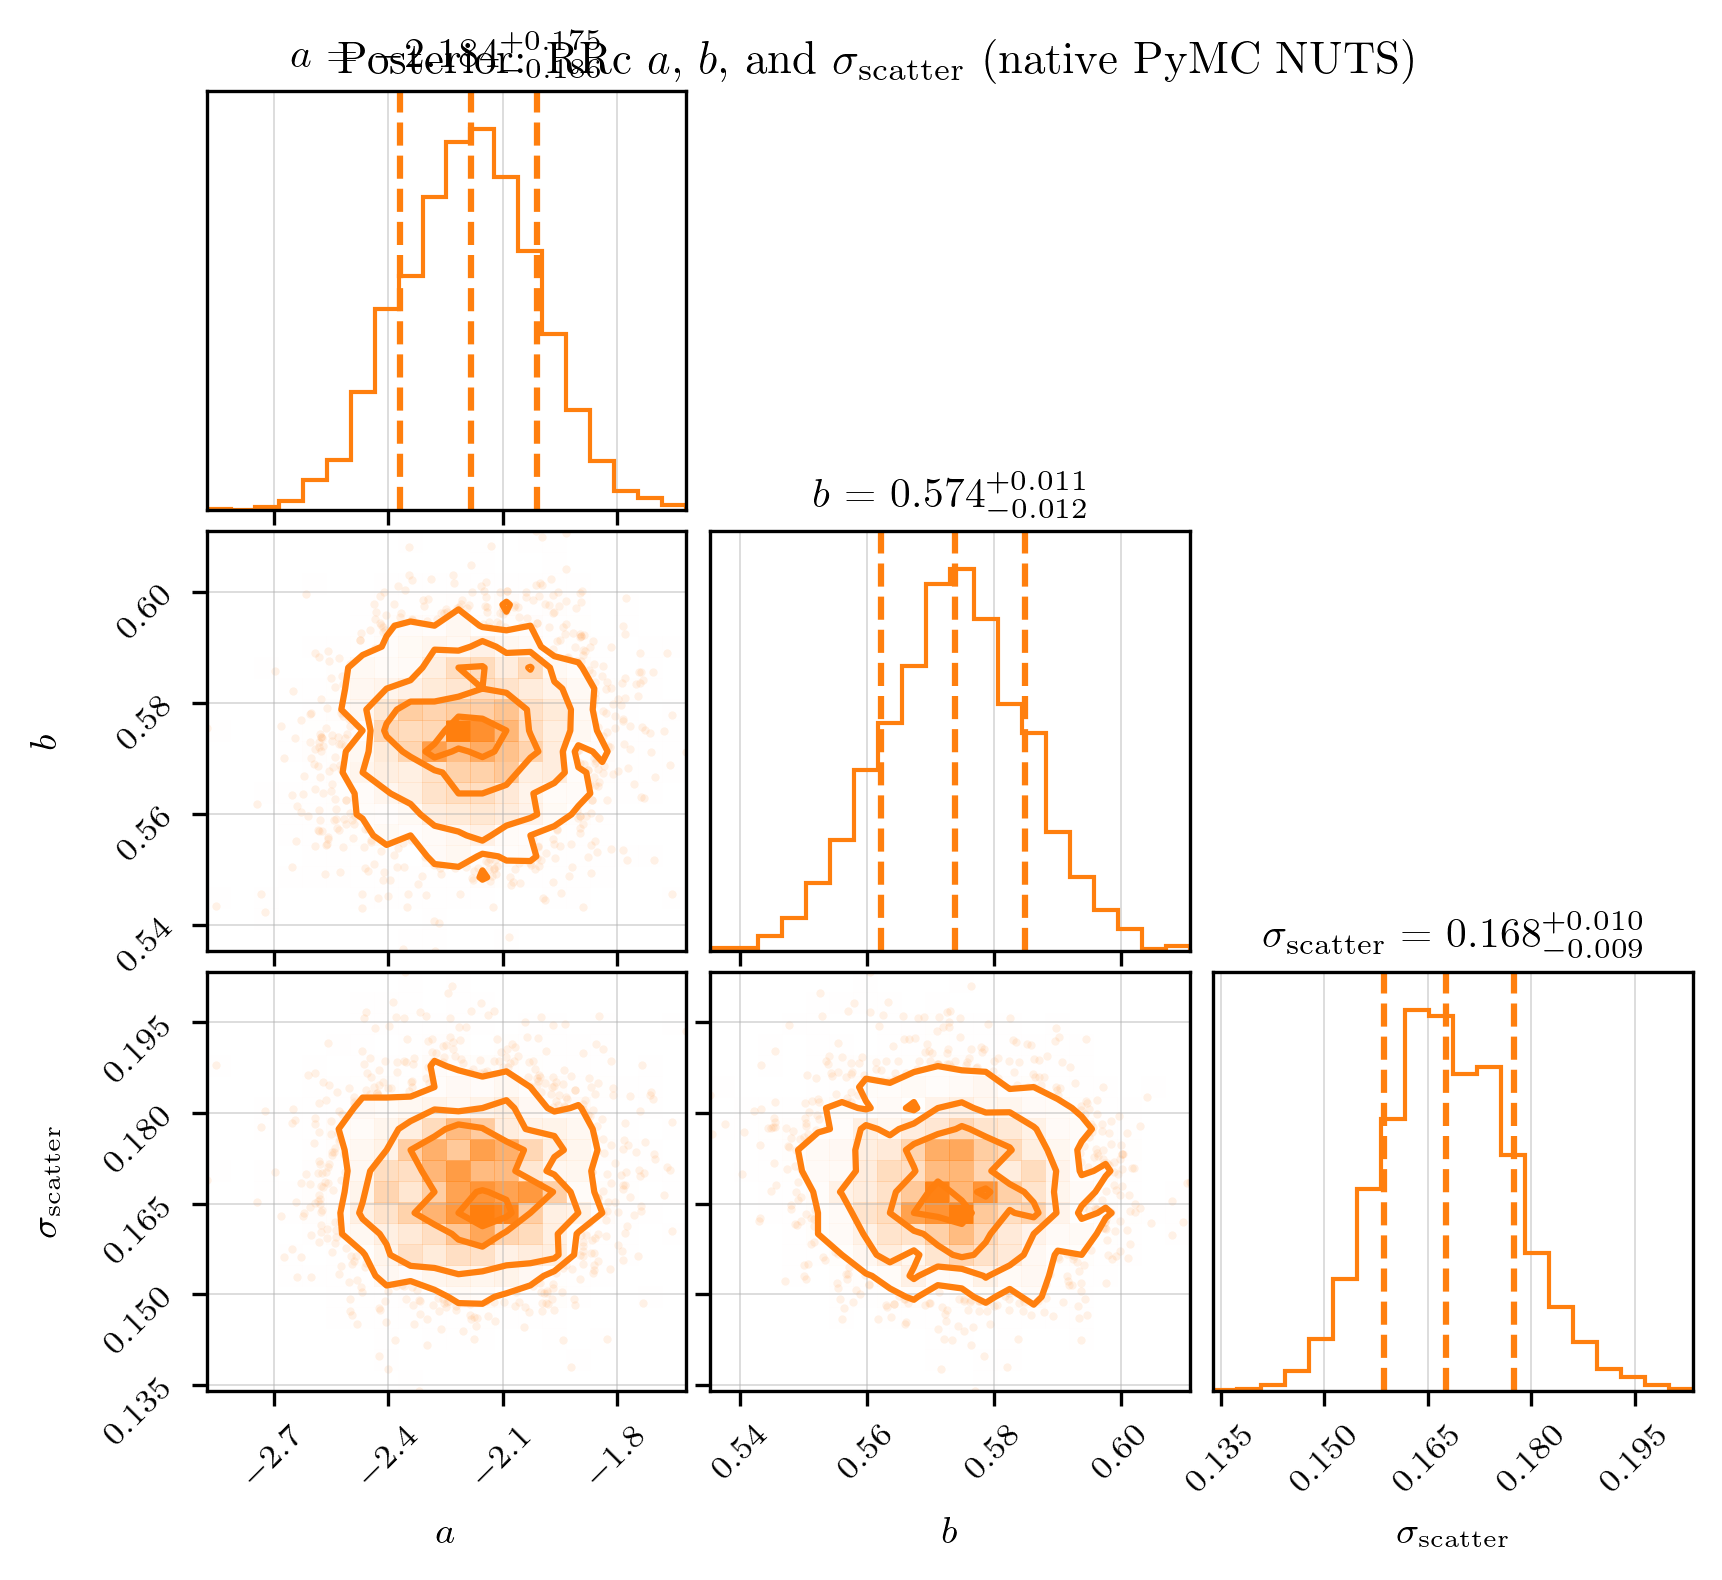

In [27]:
fig = plot_corner(
    rrc_nuts_native.display,
    color=mcmc_sampler_color("RRc", "native"),
)
fig.suptitle(r'Posterior: RRc $a$, $b$, and $\sigma_{\rm scatter}$ (native PyMC NUTS)')
plt.show()

In [28]:
rrc_summary = table.Table(rows=[rrc_mh.summary, rrc_nuts_potential.summary, rrc_nuts_native.summary])
rrc_summary


class,method,acceptance,a,a_minus,a_plus,b,b_minus,b_plus,sigma_scatter,sigma_minus,sigma_plus
str3,str19,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
RRc,Metropolis-Hastings,0.53,-2.2082,0.1836,0.1684,0.5734,0.0112,0.0117,0.1681,0.0088,0.0093
RRc,NUTS + Potential,0.837,-2.1926,0.177,0.1818,0.5734,0.0111,0.0111,0.1683,0.0094,0.0094
RRc,Native PyMC NUTS,0.839,-2.184,0.1857,0.1746,0.5738,0.0116,0.0111,0.1676,0.0089,0.0099


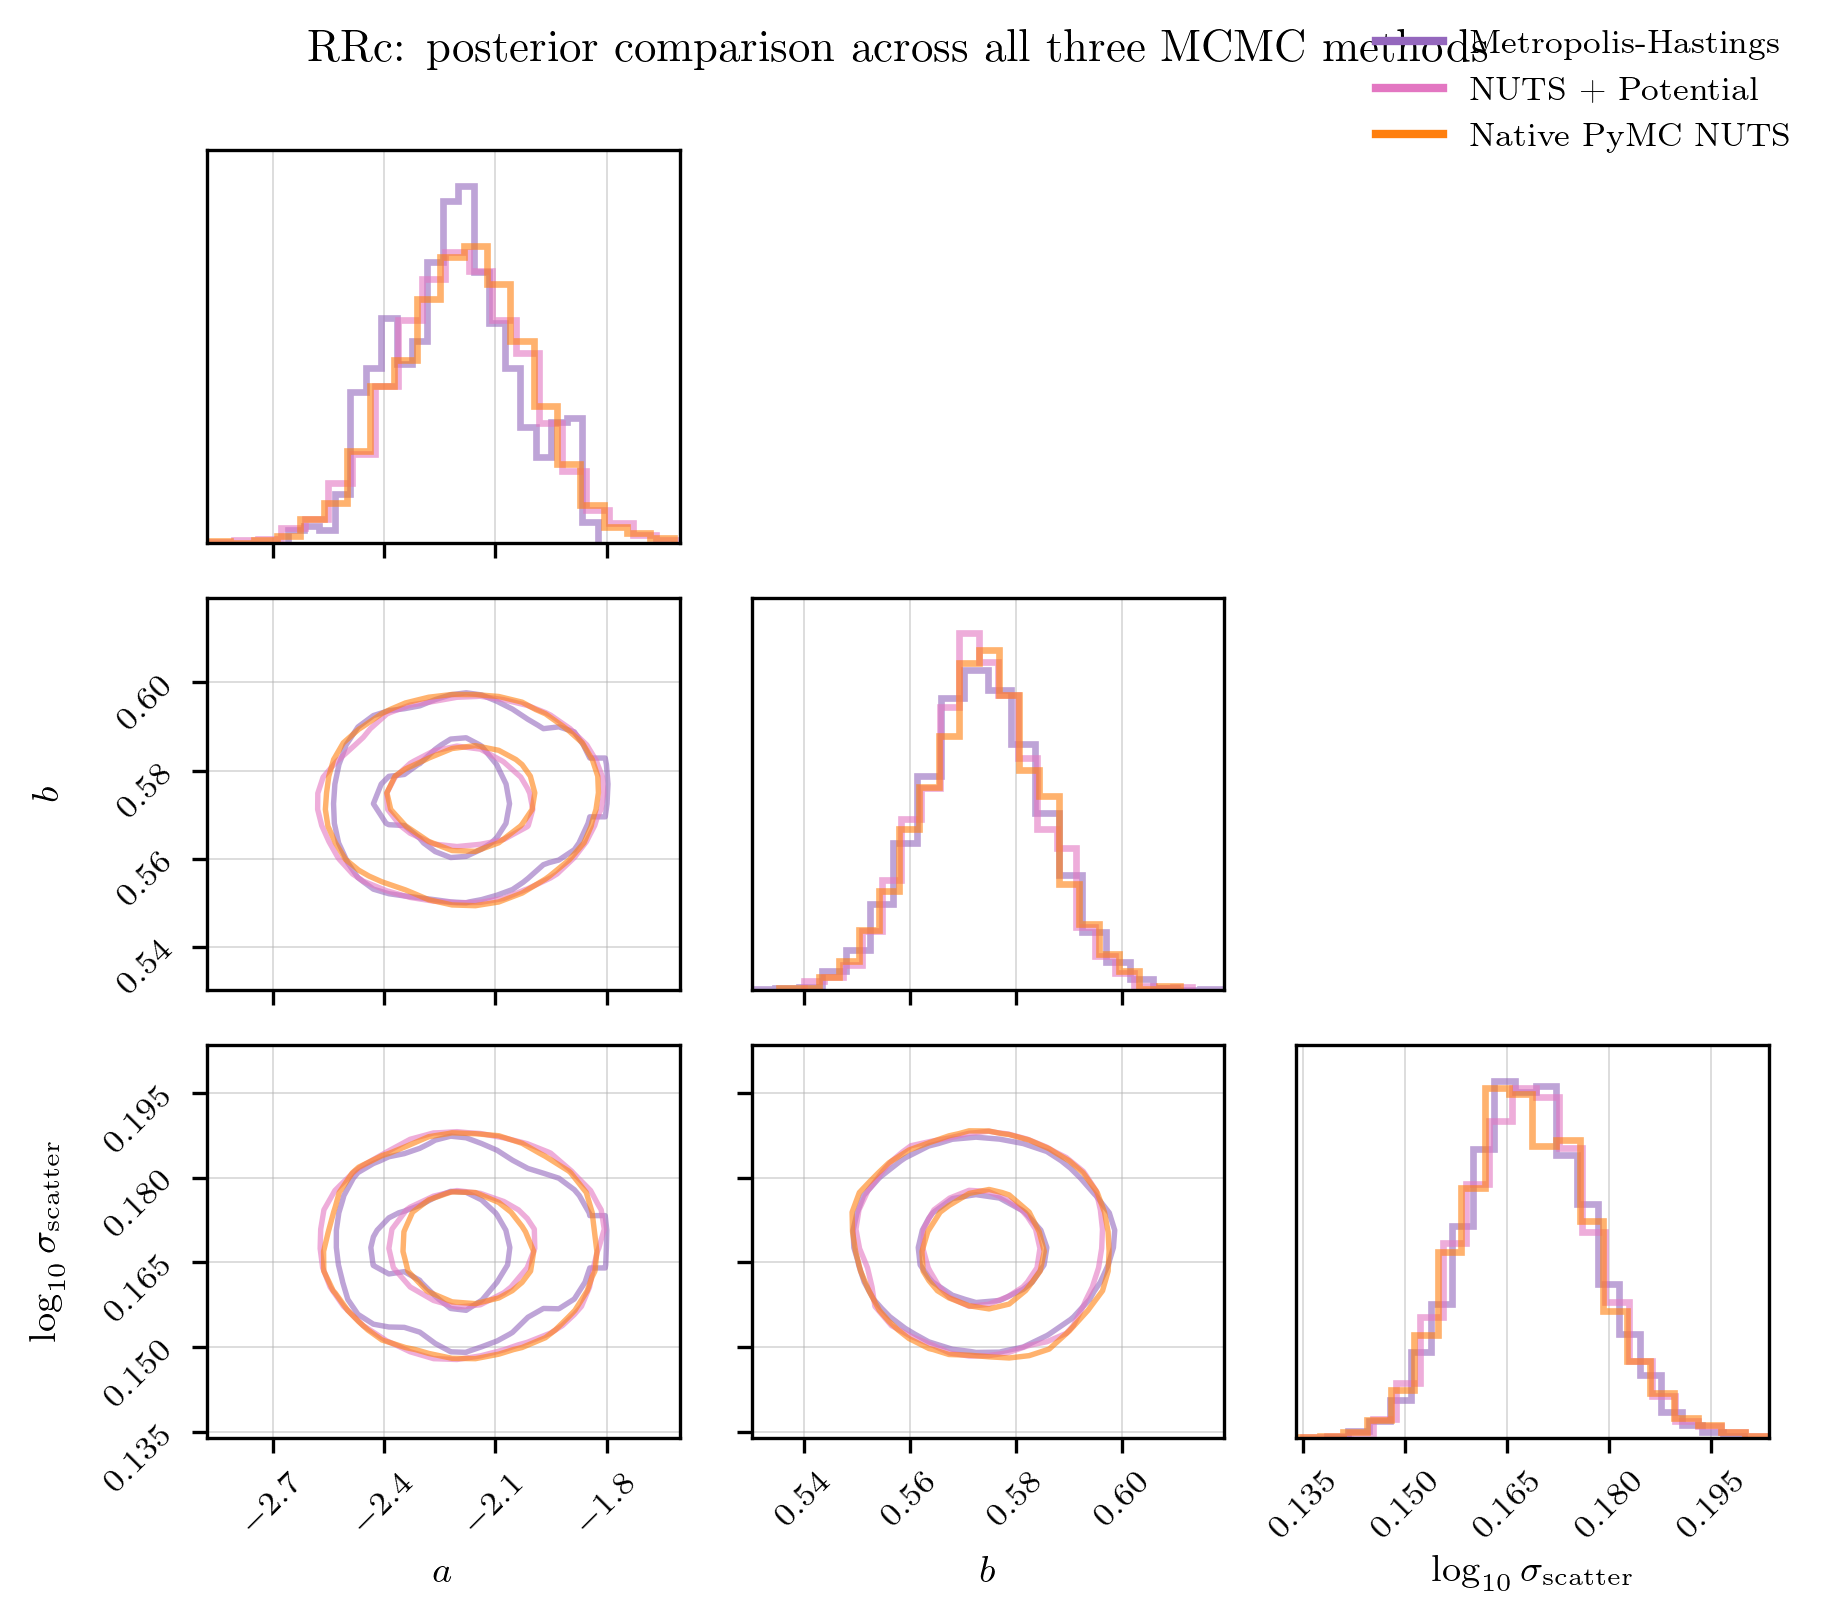

In [29]:
fig = plot_pl_sampler_comparison_corner(
    {
        "Metropolis-Hastings": rrc_mh.display.samples[rrc_mh.display.n_burn:],
        "NUTS + Potential": rrc_nuts_potential.display.samples[rrc_nuts_potential.display.n_burn:],
        "Native PyMC NUTS": rrc_nuts_native.display.samples[rrc_nuts_native.display.n_burn:],
    },
    class_label="RRc",
    save_name="fig_methods_corner_rrc.pdf",
)
fig.suptitle(r"RRc: posterior comparison across all three MCMC methods", y=1.01)
plt.show()

The RRc section repeats exactly the same statistical model and diagnostic logic used for RRab. That means the interpretation of the plots is unchanged: traces are checking stationarity and mixing, corner plots are showing uncertainty and parameter covariance, and the posterior predictive band is testing whether the fitted distribution is wide enough to describe the observed subclass relation once all modeled error terms are included. The centered parameterization again makes the intercept easier to interpret and usually softens slope-intercept correlation, but any remaining covariance is still scientifically real posterior structure rather than something to hide.

The handout-style sampled-line view is shown below for RRc as well. As above, it isolates the posterior spread in the mean relation, while the predictive envelope that follows is the fuller uncertainty display.

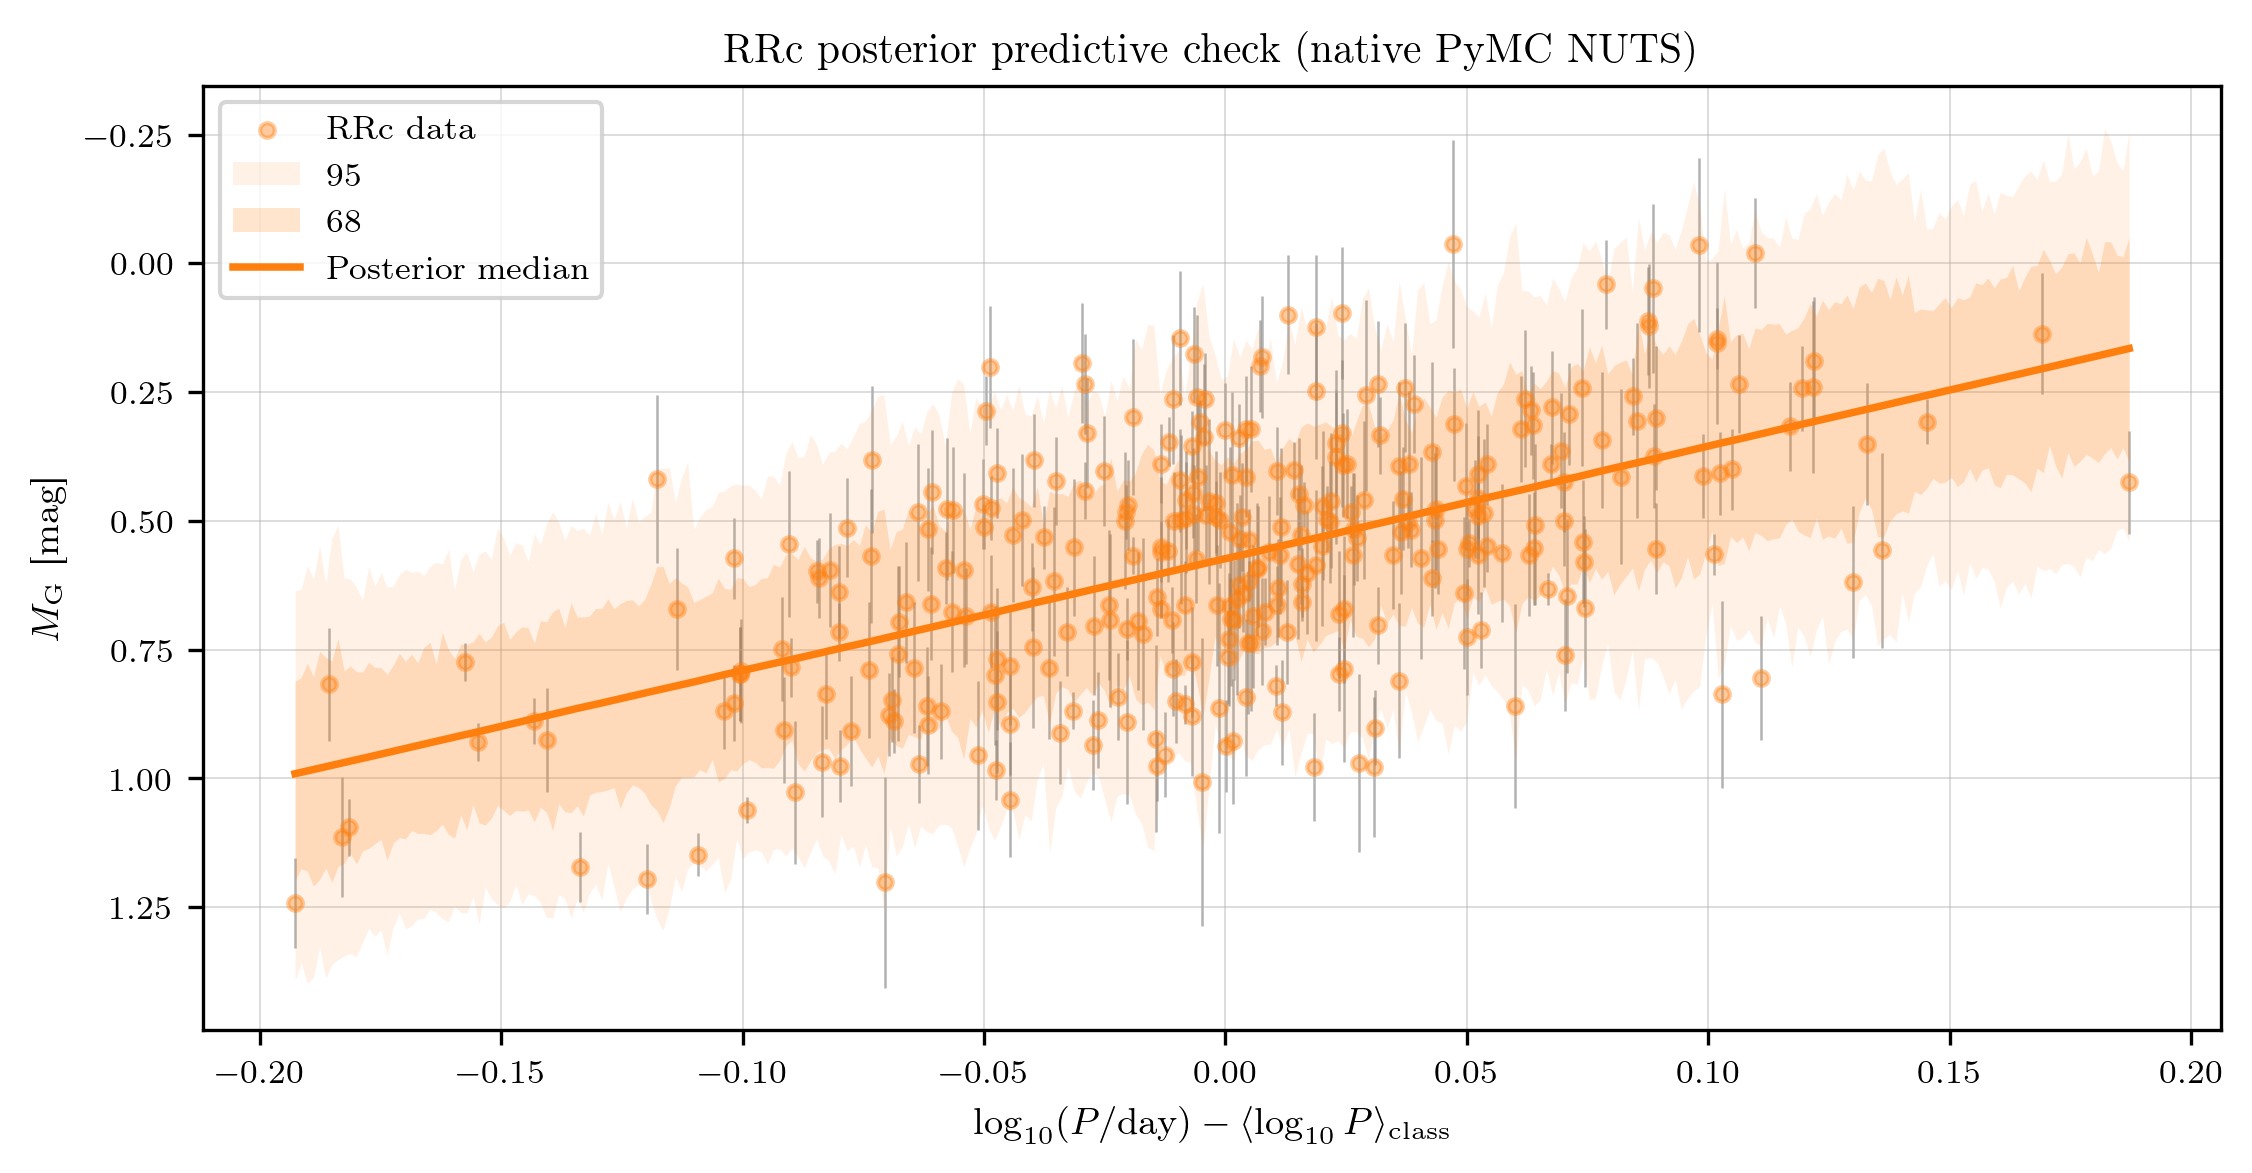

In [30]:
ax = plot_pl_posterior_predictive(
    rrc_ctx,
    rrc_nuts_native.samples[rrc_nuts_native.display.n_burn:],
    save="fig_pl_posterior_rrc.pdf",
)
ax.set_title('RRc posterior predictive check (native PyMC NUTS)')
plt.show()

## RRab vs RRc Comparison

The two subclass-specific fits can now be compared directly. Because the predictor is centered **within each class**, the intercept $b$ is not evaluated at the same raw period for RRab and RRc, so the cleanest physical comparison is through the **slope**, the **intrinsic scatter**, and the posterior predictive curves in raw $\log_{10}P$ space.

That distinction matters for interpretation. A difference in slope implies a genuine change in how luminosity scales with period between the two pulsation modes. A difference in $\sigma_{\rm scatter}$ tells us about the width of the subclass relation after observational uncertainties and propagated period errors are accounted for. The overplotted posterior predictive curves are therefore the most direct visual summary of whether the two subclasses really trace the same optical relation or whether a single common fit would blur physically distinct behavior.


The comparison table below summarizes the posterior medians and central credible ranges from the native NUTS fits. Those summary numbers are useful, but they should be interpreted together with the predictive plot and corner diagnostics. In particular, the class-specific intercepts are referenced to different mean log-periods, and the table does not show parameter covariance or chain autocorrelation, so the visual comparison in raw $\log_{10}P$ space is the cleanest way to judge whether the two subclasses really trace different optical relations.


In [31]:
comparison_summary = table.Table(
    rows=[
        rrab_nuts_native.summary,
        rrc_nuts_native.summary,
    ]
)
comparison_summary


class,method,acceptance,a,a_minus,a_plus,b,b_minus,b_plus,sigma_scatter,sigma_minus,sigma_plus
str4,str16,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
RRab,Native PyMC NUTS,0.821,-2.2316,0.127,0.1295,0.6531,0.0088,0.0082,0.1762,0.0076,0.0077
RRc,Native PyMC NUTS,0.839,-2.184,0.1857,0.1746,0.5738,0.0116,0.0111,0.1676,0.0089,0.0099


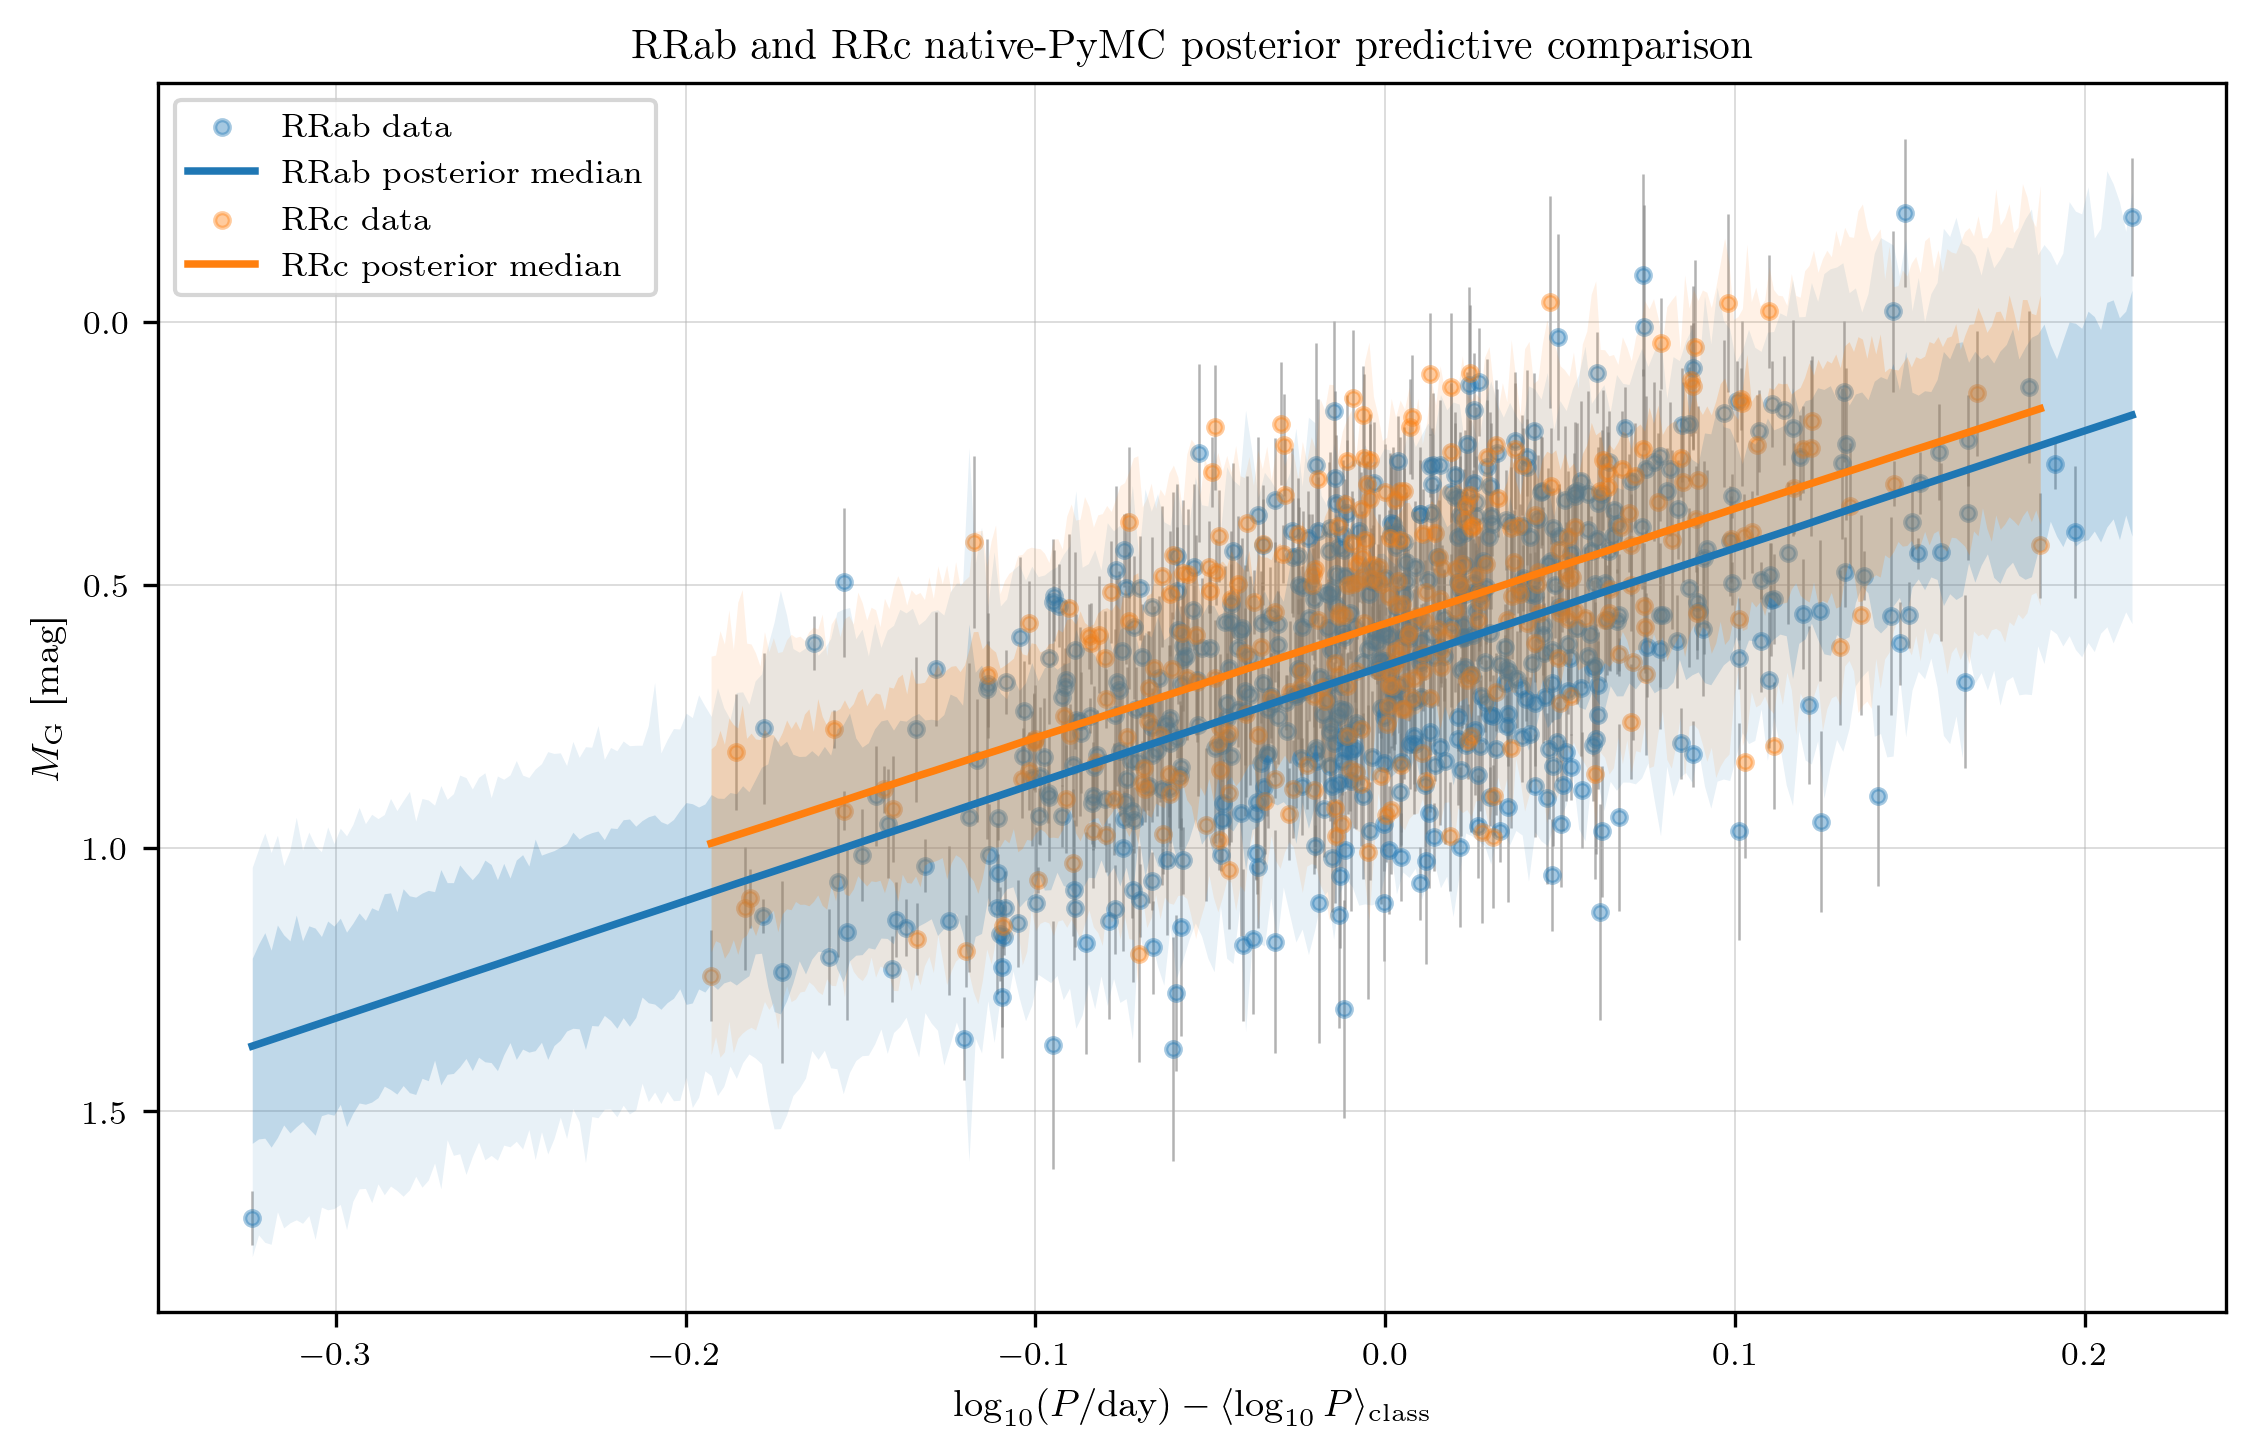

In [32]:
ax = plot_pl_posterior_predictive_comparison(
    rrab_ctx,
    rrab_nuts_native.samples,
    rrc_ctx,
    rrc_nuts_native.samples,
)
ax.set_title('RRab and RRc native-PyMC posterior predictive comparison')
plt.show()


The final comparison figure should be read as a predictive comparison in raw period space rather than as a direct intercept comparison. Because the centered predictor is different in RRab and RRc, the posterior median curves and predictive envelopes are the most physically interpretable way to compare the subclasses on the same axes. This is also why the figure carries more information than a slope-intercept table alone: it preserves the posterior geometry after transforming back into the observed period coordinate.


## Analysis and Discussion

The literature-backed expectation is that the RRab and RRc optical period-luminosity relations should not be forced into a single common fit unless one is very careful about overtone transformations and possible residual subclass offsets ([Narloch et al. 2024](https://www.aanda.org/articles/aa/full_html/2024/09/aa50364-24/aa50364-24.html); [Klein et al. 2014](https://academic.oup.com/mnrasl/article/440/1/L96/1396776)). This notebook is designed to test that directly with the cleaned Gaia calibration sample.

A successful result should show four things. First, within **each subclass**, the Metropolis-Hastings chain, the NUTS-with-`Potential` model, and the native PyMC model should agree on the same posterior region and broadly the same covariance geometry. That agreement checks the numerical implementation rather than the astrophysics. Second, the traces should not show obvious sticky plateaus or unresolved burn-in behavior, even though this notebook still stops short of a full multi-chain convergence analysis. Third, the posterior predictive checks should show that the fitted spread is broadly consistent with the width of the subclass data once the absolute-magnitude errors, the propagated period term, and the intrinsic scatter are all included. Fourth, the RRab and RRc best-fitting relations should not in general be assumed identical just because both are RR Lyrae: they represent different pulsation modes, so differences in slope or normalization are physically plausible.

The excluded RRd stars are important context. RRd is not merely a noisy extension of RRc; it is a distinct **double-mode** class in both Gaia classification and in current distance-calibration work ([Clementini et al. 2023](https://www.aanda.org/articles/aa/full_html/2023/06/aa43964-22/aa43964-22.html); [Shi et al. 2023](https://doi.org/10.1038/s41550-023-02011-y)). With only eight RRd stars in the cleaned sample, any attempt to fit a standalone RRd optical PL relation here would be dominated by small-number noise and, more importantly, would still be mismatched to the more appropriate RRd-specific period-ratio formulation.

It is also important to interpret $\sigma_{\rm scatter}$ physically rather than as a purely abstract nuisance parameter. In this notebook it absorbs whatever width remains after the quoted $\sigma_M$ values and the propagated period term have been accounted for. That residual width can come from metallicity spread, evolutionary-state differences, residual extinction, subclass-dependent light-curve physics, and the fact that the Gaia $G$ band is very broad. So the fitted intrinsic scatter is best viewed as a compact summary of unresolved astrophysical and observational complexity, not as a claim that one simple mechanism is responsible for all of the dispersion.

The remaining methodological caveat is that this analysis still works in direct $M_G$ space. In the Gaia literature, ABL, parallax-space Bayesian likelihoods, and hierarchical Bayesian calibration are more common final-publication solutions because they avoid the main inverse-parallax biases directly ([Gaia Collaboration et al. 2017](https://www.aanda.org/articles/aa/full_html/2017/09/aa29925-16/aa29925-16.html); [Luri et al. 2018](https://www.aanda.org/articles/aa/full_html/2018/08/aa32964-18/aa32964-18.html); [Muraveva et al. 2018](https://academic.oup.com/mnras/article/481/1/1195/5075596); [Delgado et al. 2019](https://www.aanda.org/articles/aa/full_html/2019/03/aa32945-18/aa32945-18.html)). Those are common practice in the literature rather than special-case workarounds.

### References
- Clementini et al. (2023), *Gaia Data Release 3 -- Specific processing and validation of all-sky RR Lyrae and Cepheid stars*, A&A 674, A18. https://www.aanda.org/articles/aa/full_html/2023/06/aa43964-22/aa43964-22.html
- Gaia Collaboration et al. (2017), *ABL and Bayesian fitting with Gaia parallaxes*. https://www.aanda.org/articles/aa/full_html/2017/09/aa29925-16/aa29925-16.html
- Hogg, Bovy, & Lang (2010), *Data analysis recipes: Fitting a model to data*. https://arxiv.org/abs/1008.4686
- Hoffman & Gelman (2014), *The No-U-Turn Sampler*, JMLR 15, 1593. https://jmlr.org/papers/v15/hoffman14a.html
- Klein et al. (2014), *A mid-infrared period-luminosity relation for RR Lyrae stars*. https://academic.oup.com/mnrasl/article/440/1/L96/1396776
- Luri et al. (2018), *Using Gaia parallaxes safely*. https://www.aanda.org/articles/aa/full_html/2018/08/aa32964-18/aa32964-18.html
- Muraveva et al. (2018), *Bayesian RR Lyrae calibration with Gaia parallaxes*. https://academic.oup.com/mnras/article/481/1/1195/5075596
- Narloch et al. (2024), *On the use of RR Lyrae stars for distance determination*. https://www.aanda.org/articles/aa/full_html/2024/09/aa50364-24/aa50364-24.html
- Delgado et al. (2019), *Hierarchical Bayesian RR Lyrae PLZ calibration*. https://www.aanda.org/articles/aa/full_html/2019/03/aa32945-18/aa32945-18.html
- Shi et al. (2023), *The distance scale of double-mode RR Lyrae stars*, Nature Astronomy. https://doi.org/10.1038/s41550-023-02011-y


## Notebook Handoff

The file `rrlyrae_optical_pl_comparison_data.npz` is the notebook handoff artifact for `04.ipynb`. It stores the summarized RRab and RRc native-PyMC Gaia $G$-band relation values that `04.ipynb` uses for the literature-comparison plot and discussion.


In [33]:
output_path = Path("rrlyrae_optical_pl_comparison_data.npz")
comparison_export = {
    "RRab": build_optical_pl_comparison_data(rrab_ctx, rrab_nuts_native.samples),
    "RRc": build_optical_pl_comparison_data(rrc_ctx, rrc_nuts_native.samples),
}
save_optical_pl_comparison_data(output_path, comparison_export)

{
    "path": str(output_path.resolve()),
    "classes": list(comparison_export),
}


{'path': '/Users/junruiting/GitHub/ay-128/labs/01/rrlyrae_optical_pl_comparison_data.npz',
 'classes': ['RRab', 'RRc']}